In [1]:
import os
import urllib.request
import zipfile
from functools import partial

import pandas as pd
import xarray as xr
import pynncml

from pynncml.datasets.dataset import LinkDataset
from pynncml.datasets.gauge_data import PointSensor
from pynncml.datasets import PointSet
import numpy as np
import netCDF4 as nc

from pynncml.datasets.xarray_processing import xarray2link, LinkSelection

from scipy.interpolate import interp1d

import sys
from pathlib import Path

from load_link_set import *

C:\Users\gabir\Documents\OpenMesh_pynncml\PyNNcml\pynncml\model_zoo\model_common.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Find optimal threshold for rain detection for each high frequency sublink

In [2]:
import os
from pathlib import Path

# find the OpenMesh-1 root automatically
root = Path.cwd()

while root.name != "OpenMesh_pynncml":
    root = root.parent

os.chdir(root)
print("Working directory set to:", root)


Working directory set to: c:\Users\gabir\Documents\OpenMesh_pynncml


In [3]:
import sys
from pathlib import Path

# Add the notebooks directory to Python path
# Since Cell 1 changes cwd to project root, we need the relative path from there
notebooks_dir = Path.cwd() / 'src' / 'analysis' / 'pynncml_experiments' / 'notebooks'
if str(notebooks_dir) not in sys.path:
    sys.path.insert(0, str(notebooks_dir))

Import files

In [4]:
# ============================================
# PATH CONFIGURATION
# ============================================
from pathlib import Path

# Choose user
USER = "gabir"  # Options: "user" or "dror"

# Base path (relative to project root - Cell 1 sets working directory to project root)
BASE_PATH = Path("dataset")

# All paths built from base path
linkspath = str(BASE_PATH / "links" / "ds_openmesh.nc")
metapath = str(BASE_PATH / "links" / "links_metadata.csv")
# Note: pws_opensense_sample_jan.nc is in dataset root, not in weather stations folder
gaugespath = str(BASE_PATH / "weather stations" / "pws_opensense_sample_jan.nc")
gaugemetapath = str(BASE_PATH / "weather stations" / "pws_metadata.csv")

# Load data
with xr.open_dataset(linkspath) as ds:
    pass
links_meta = pd.read_csv(metapath)




1. Gauge data to Point Sensors

In [5]:
# CREATE POINT SENSORS
ps = guage_to_linkset(gaugemetapath, gaugespath)


CONVERTING NETCDF GROUPS TO XARRAY DICT

  ✓ KNYNEWYO1472: 4402 records
  ✓ KNYNEWYO1659: 4606 records
  ✓ KNYNEWYO1288: 3743 records
  ✓ KNYNEWYO1896: 4606 records
  ✓ KNYNEWYO1921: 4605 records
  ✓ KNYNEWYO1931: 4606 records
  ✓ KNYNEWYO1313: 4604 records
  ✓ KNYNEWYO1918: 4604 records
  ✓ KNYNEWYO1298: 4606 records
  ✓ KNYNEWYO1388: 4599 records
  ✓ KNYNEWYO1606: 4606 records
  ✓ KNYNEWYO1943: 290 records
  ✓ KNYNEWYO1348: 4606 records
  ✓ KNYNEWYO1942: 373 records
  ✓ KNYNEWYO1238: 4544 records
  ✓ KNYNEWYO1401: 4587 records
  ✓ KNYNEWYO1824: 4605 records
  ✓ KNYNEWYO343: 4606 records
  ✓ KNYNEWYO1626: 4604 records
  ✓ KNYNEWYO1747: 1171 records
  ✓ KNYNEWYO589: 4605 records
  ✓ KNYNEWYO1591: 4606 records
  ✓ KNYNEWYO638: 3958 records
  ✓ KNYNEWYO1796: 4606 records
  ✓ KNYNEWYO1805: 4534 records
  ✓ KNYNEWYO1622: 4606 records
  ✓ KNYNEWYO1024: 1506 records
  ✓ KNYNEWYO1533: 4580 records
  ✓ KNYNEWYO1651: 1534 records
  ✓ KNYNEWYO1120: 4606 records
  ✓ KNYNEWYO1900: 4605 records
  

2. Create LinkSet

In [6]:
# Create the LinkSet from 24/01 until 30/01
link_set = patched_xarray2link_with_gauges(ds, ps, max_distance=5000, change2min_max=True, time_slice=True, start='2024-01-15', end='2024-01-30')

print(f"✅ Created LinkSet with {len(link_set)} sublinks")

Processing sublinks:   0%|          | 0/3 [00:00<?, ?it/s]

c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Docum


Processing Summary:
  ✅ Valid links created: 100
  ⚠️  Skipped (missing coordinates): 0
  ⚠️  Skipped (no RSL data): 125
  📊 Total processed: 225

✅ Created LinkSet with 100 sublinks


Get high frequency links:

In [7]:
highfreqID = []
for i in range(0,len(link_set)):
    if link_set.get_link(i).meta_data.frequency >= 65:
        highfreqID.append(i)

In [8]:
HF_set = keep_links(link_set, highfreqID, True)
print(f'There are {len(HF_set)} high frequency sublinks')

There are 19 high frequency sublinks


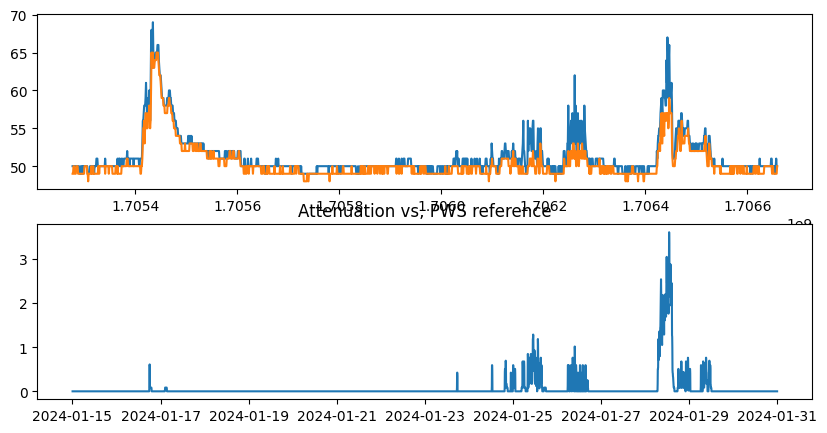

In [9]:
link0 = HF_set.get_link(0)

_, axs = plt.subplots(2, 1, figsize=(10, 5))
plt.title('Attenuation vs, PWS reference')

axs[0].plot(link0.time_array, link0.attenuation()[0,:,0])
axs[0].plot(link0.time_array, link0.attenuation()[0,:,1])



axs[1].plot(link0.gauge_ref[0].time_array.astype('datetime64[s]'), link0.gauge_ref[0].data_array)



## Find optimal threshold for each link to maximize TPR/FPR

No optimization:

Sublink index in set: 0, frequency 68.04


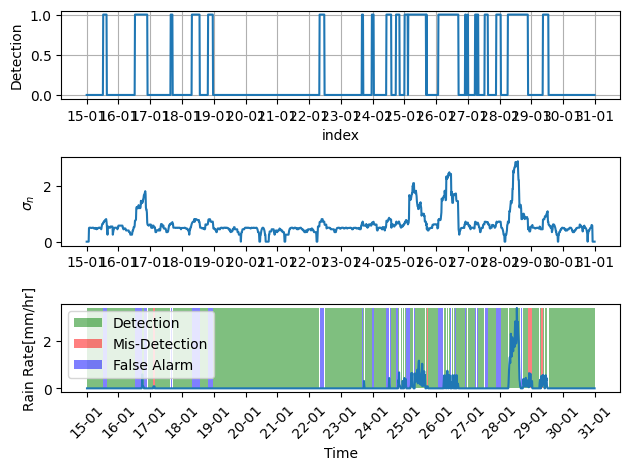

Accuracy:  82.5%
Precision: 40.4%
Recall:    80.4%
Sublink index in set: 1, frequency 68.04


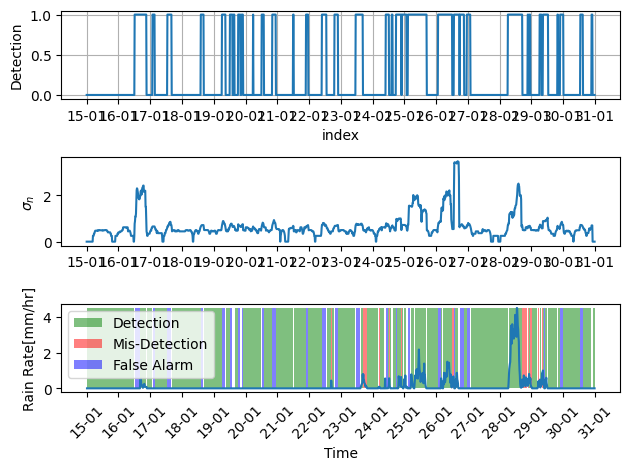

Accuracy:  79.2%
Precision: 45.4%
Recall:    74.3%
Sublink index in set: 2, frequency 68.04


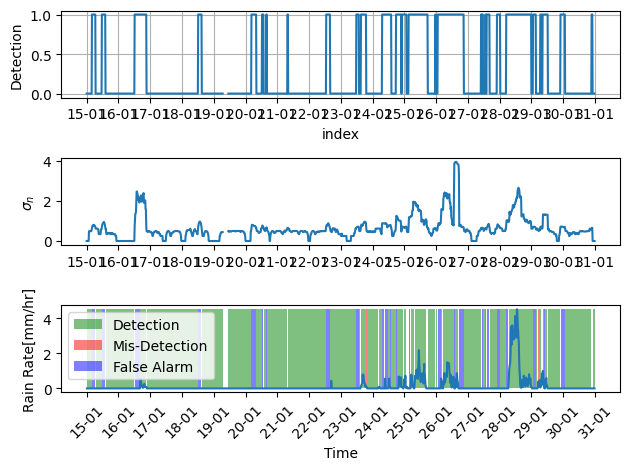

Accuracy:  82.2%
Precision: 52.0%
Recall:    89.1%
Sublink index in set: 3, frequency 65.88


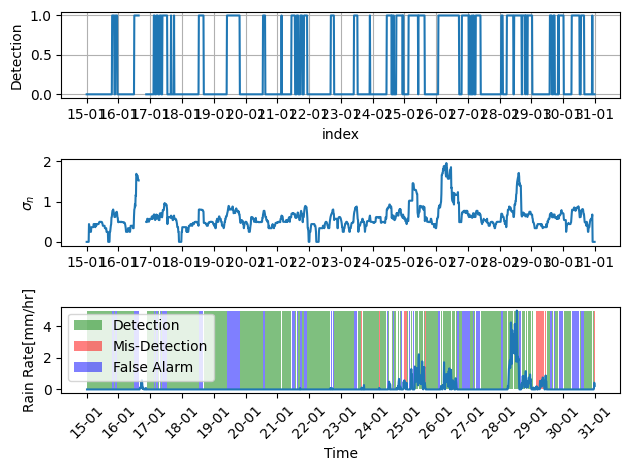

Accuracy:  72.1%
Precision: 32.3%
Recall:    70.7%
Sublink index in set: 4, frequency 68.04


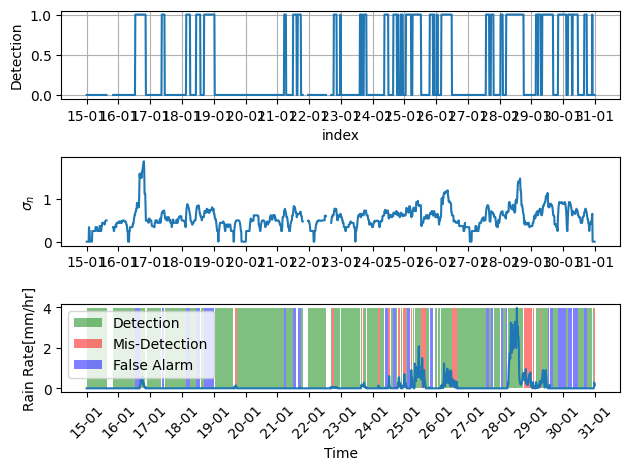

Accuracy:  71.0%
Precision: 42.2%
Recall:    58.6%
Sublink index in set: 5, frequency 69.12


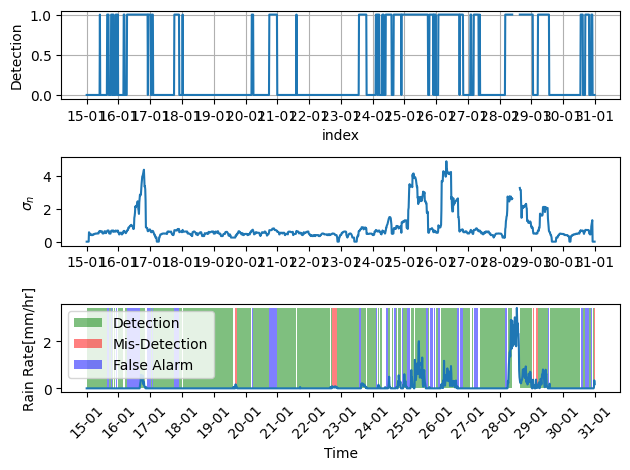

Accuracy:  77.3%
Precision: 47.8%
Recall:    82.8%
Sublink index in set: 6, frequency 69.12


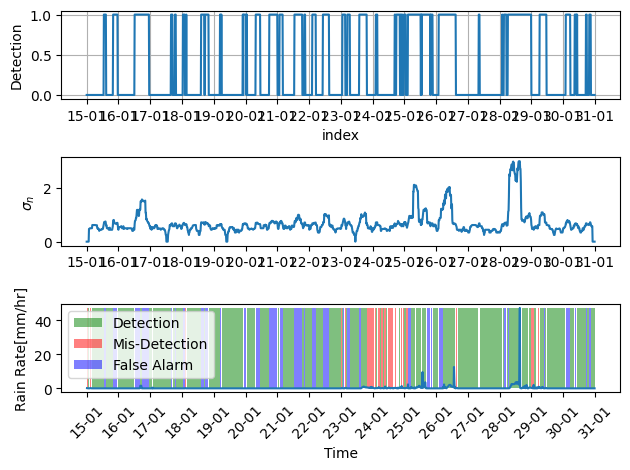

Accuracy:  69.9%
Precision: 38.8%
Recall:    62.7%
Sublink index in set: 7, frequency 68.04


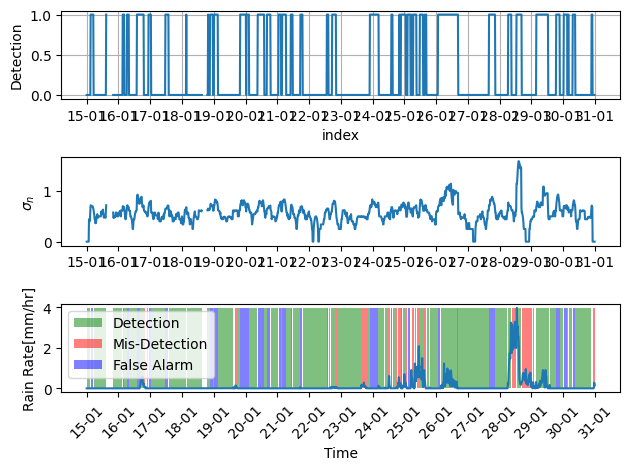

Accuracy:  69.4%
Precision: 38.2%
Recall:    52.4%
Sublink index in set: 8, frequency 68.04


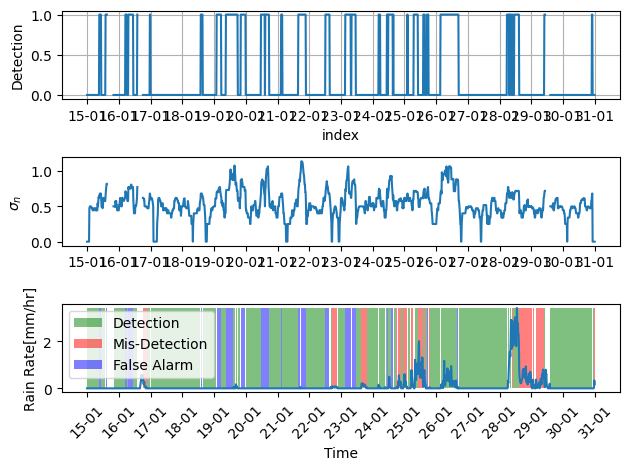

Accuracy:  70.5%
Precision: 35.7%
Recall:    39.1%
Sublink index in set: 9, frequency 68.04


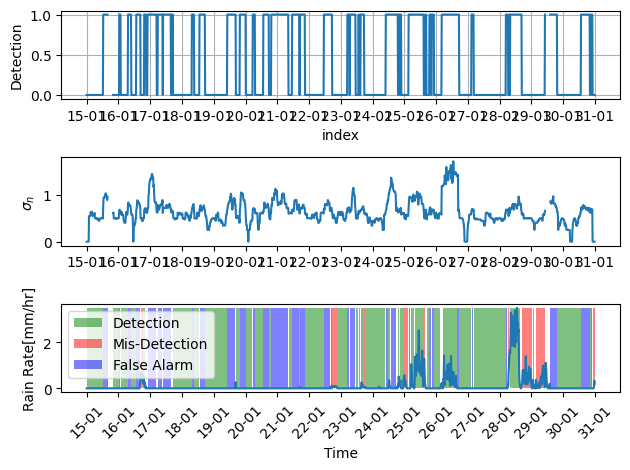

Accuracy:  59.4%
Precision: 25.7%
Recall:    54.6%
Sublink index in set: 10, frequency 68.04


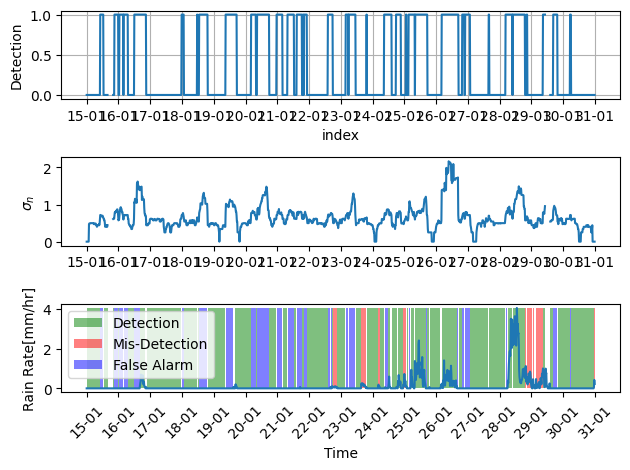

Accuracy:  68.2%
Precision: 37.3%
Recall:    67.2%
Sublink index in set: 11, frequency 68.04


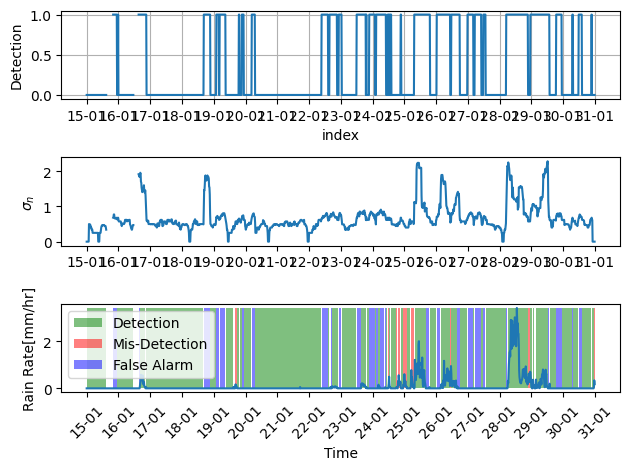

Accuracy:  74.2%
Precision: 46.7%
Recall:    79.4%
Sublink index in set: 12, frequency 68.04


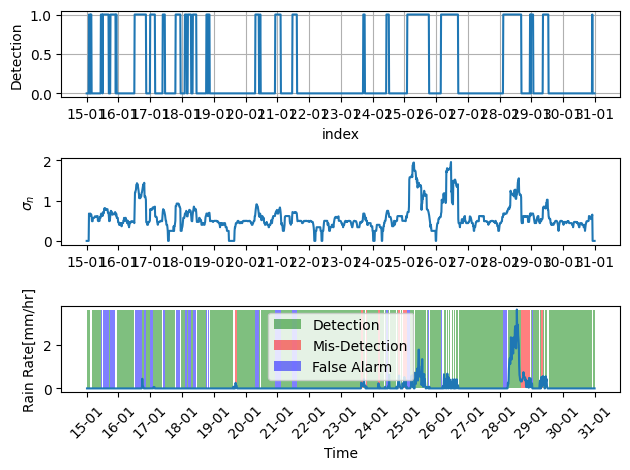

Accuracy:  78.1%
Precision: 40.1%
Recall:    64.6%
Sublink index in set: 13, frequency 68.04


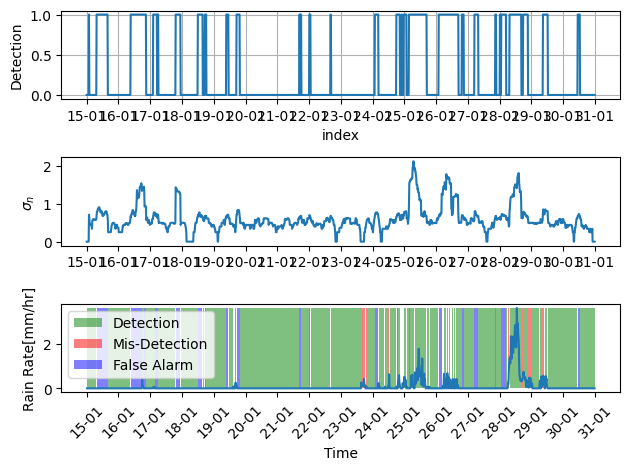

Accuracy:  79.1%
Precision: 42.1%
Recall:    68.9%
Sublink index in set: 14, frequency 68.04


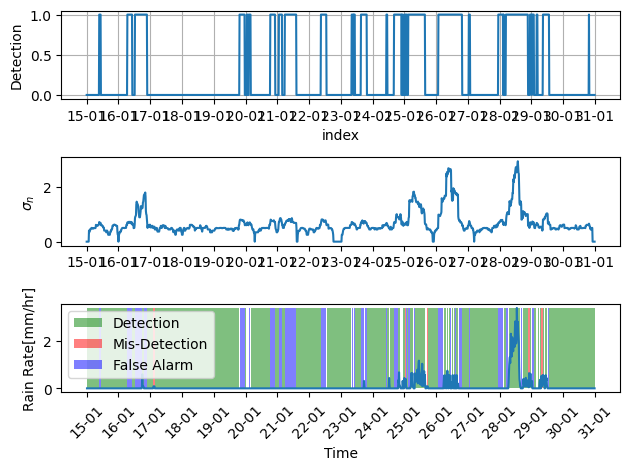

Accuracy:  78.2%
Precision: 35.0%
Recall:    84.0%
Sublink index in set: 15, frequency 65.88


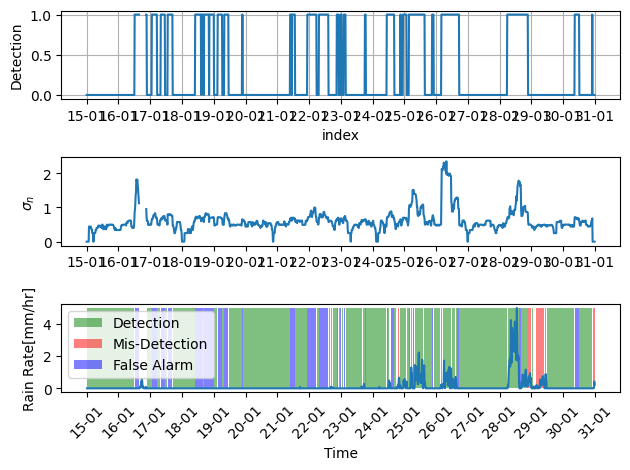

Accuracy:  74.3%
Precision: 34.2%
Recall:    67.7%
Sublink index in set: 16, frequency 68.04


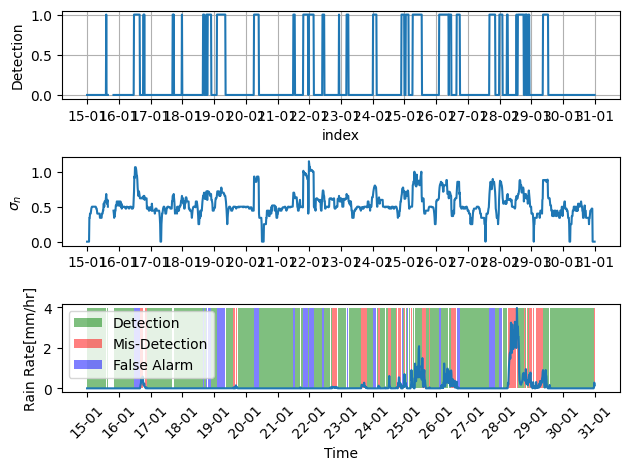

Accuracy:  72.5%
Precision: 37.2%
Recall:    35.1%
Sublink index in set: 17, frequency 65.88


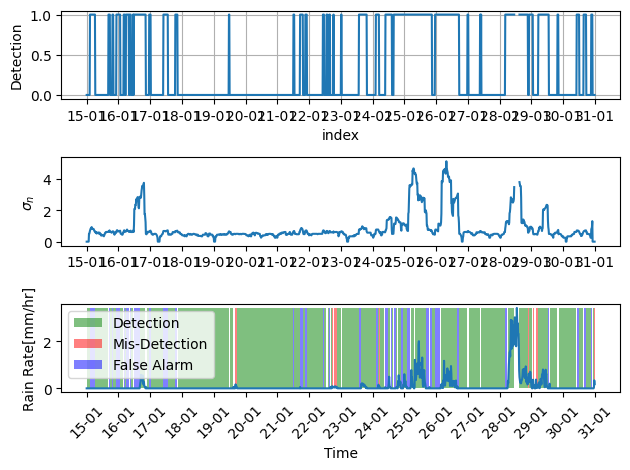

Accuracy:  78.3%
Precision: 49.1%
Recall:    82.3%
Sublink index in set: 18, frequency 68.04


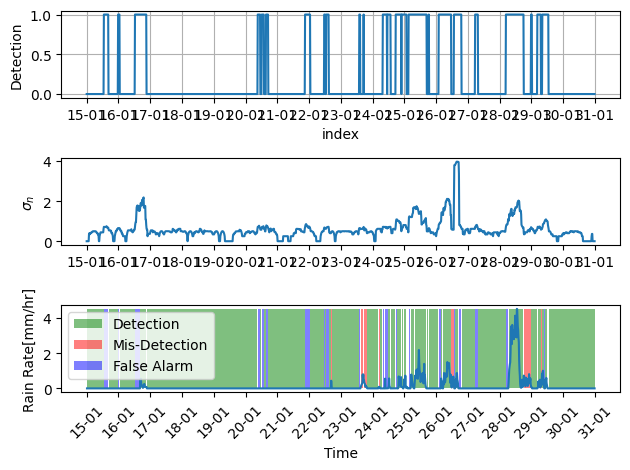

Accuracy:  85.0%
Precision: 56.3%
Recall:    76.4%


In [10]:
threshold = 0.65
stats = []
for i in range(0,len(HF_set)):
    print(f'Sublink index in set: {i}, frequency {HF_set.get_link(i).meta_data.frequency}')
    classification_plot(HF_set.get_link(i), threshold, 15, is_minmax=True)


Find optimal threshold:

In [11]:
thresholds = np.arange(0, 0.85, 0.05)

In [15]:
TPRs = [classification_plot(link0, t, 15, is_minmax=True, plot=False)['TPR'] for t in thresholds]
FPRs = [classification_plot(link0, t, 15, is_minmax=True, plot=False)['FPR'] for t in thresholds]

c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:453: RuntimeWarning: invalid value encountered in scalar divide
  stats = {"TPR":tp/(tp+fn), "FPR":fp/(fp+tn)}


Accuracy:  0.0%
Precision: 0.0%
Recall:    0.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  18.6%
Precision: 13.4%
Recall:    100.0%
Accuracy:  18.6%
Precision: 13.4%
Recall:    100.0%
Accuracy:  23.4%
Precision: 14.2%
Recall:    100.0%
Accuracy:  30.3%
Precision: 15.1%
Recall:    97.9%
Accuracy:  38.0%
Precision: 16.1%
Recall:    92.3%
Accuracy:  68.0%
Precision: 27.0%
Recall:    90.2%
Accuracy:  71.0%
Precision: 28.4%
Recall:    85.1%
Accuracy:  76.3%
Precision: 32.6%
Recall:    82.0%
Accuracy:  82.5%
Precision: 40.4%
Recall:    80.4%
Accuracy:  85.5%
Precision: 45.7%
Recall:    76.8%
Accuracy:  89.4%
Precision: 56.3%
Recall:    73.7%
Accuracy:  91.0%
Precision: 63.0%
Recall:    70.1%
Accuracy:  0.0%
Precision: 0.0%
Recall:    0.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 1

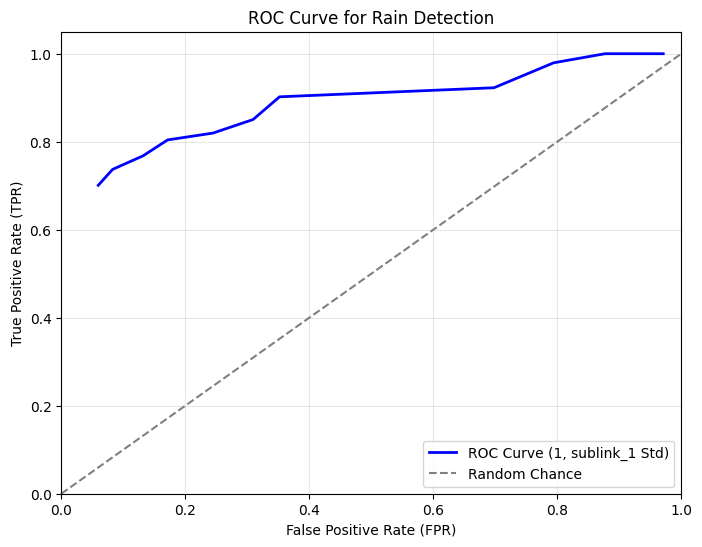

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot the ROC Curve
plt.plot(FPRs, TPRs, color='blue', lw=2, label=f'ROC Curve ({link0.meta_data.cml_id}, {link0.meta_data.sublink_id} Std)')

# Plot the "Random Guess" line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Rain Detection')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Find the threshold that renders the point closest to (0,1)

In [17]:
fpr_arr = np.array(FPRs)
tpr_arr = np.array(TPRs)
thresh_arr = np.array(thresholds)

# Calculate distance to the "Perfect" point (0, 1)
# Distance = sqrt( FPR^2 + (1-TPR)^2 )
distances = np.sqrt(fpr_arr**2 + (1 - tpr_arr)**2)

# Find the index of the minimum distance
best_idx = np.nanargmin(distances)

print(f"Best Threshold: {thresh_arr[best_idx]}")
print(f"Resulting TPR: {tpr_arr[best_idx]:.2f}")
print(f"Resulting FPR: {fpr_arr[best_idx]:.2f}")

Best Threshold: 0.65
Resulting TPR: 0.80
Resulting FPR: 0.17


Build a function to find optimal threshold value
(In load_link_set.py)

Accuracy:  0.0%
Precision: 0.0%
Recall:    0.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%
Precision: 18.9%
Recall:    100.0%
Accuracy:  22.7%

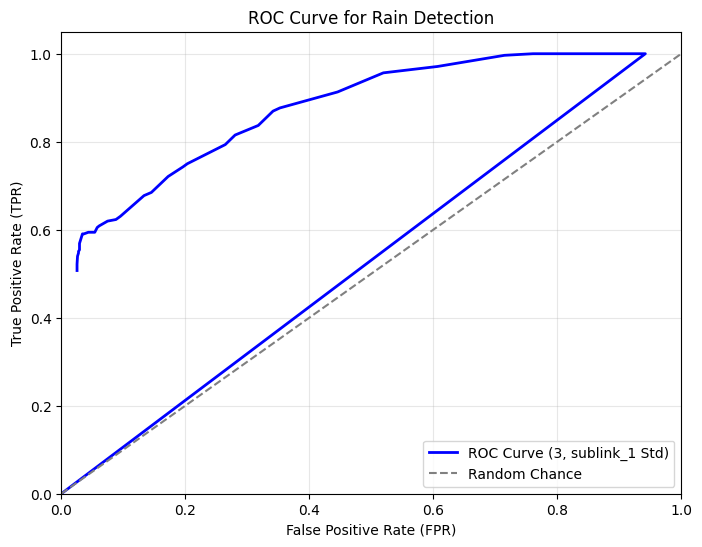

In [10]:
bestT = roc_threshold(HF_set.get_link(1), 15, True, 0.01)

In [11]:
bestT

{'Best Threshold': 0.58,
 'Resulting TPR': 0.8152173913043478,
 'Resulting FPR': 0.28038125496425736}

### Get best threshold for every high frequency sublink 

In [12]:
ROC_dict = {f'CML id {HF_set.get_link(i).meta_data.cml_id}, {HF_set.get_link(i).meta_data.sublink_id}': roc_threshold(HF_set.get_link(i), 15, True, 0.01, plot=False) for i in range(0, len(HF_set))}

Accuracy:  0.0%
Precision: 0.0%
Recall:    0.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%
Precision: 13.0%
Recall:    100.0%
Accuracy:  15.2%

In [13]:
ROC_dict

{'CML id 1, sublink_1': {'Best Threshold': 0.64,
  'Resulting TPR': 0.8041237113402062,
  'Resulting FPR': 0.1715137956748695},
 'CML id 3, sublink_1': {'Best Threshold': 0.58,
  'Resulting TPR': 0.8152173913043478,
  'Resulting FPR': 0.28038125496425736},
 'CML id 8, sublink_1': {'Best Threshold': 0.7000000000000001,
  'Resulting TPR': 0.8623188405797102,
  'Resulting FPR': 0.13757039420756234},
 'CML id 12, sublink_1': {'Best Threshold': 0.5,
  'Resulting TPR': 0.8209606986899564,
  'Resulting FPR': 0.4992211838006231},
 'CML id 17, sublink_1': {'Best Threshold': 0.49,
  'Resulting TPR': 0.8067484662576687,
  'Resulting FPR': 0.5073212747631353},
 'CML id 20, sublink_1': {'Best Threshold': 0.74,
  'Resulting TPR': 0.8052805280528053,
  'Resulting FPR': 0.1147811725846408},
 'CML id 22, sublink_1': {'Best Threshold': 0.5,
  'Resulting TPR': 0.8313609467455622,
  'Resulting FPR': 0.5538847117794486},
 'CML id 29, sublink_1': {'Best Threshold': 0.49,
  'Resulting TPR': 0.814024390243902

In [14]:
threshold_list = [i['Best Threshold'] for i in ROC_dict.values()]
threshold_list

[0.64,
 0.58,
 0.7000000000000001,
 0.5,
 0.49,
 0.74,
 0.5,
 0.49,
 0.45,
 0.49,
 0.55,
 0.6,
 0.52,
 0.49,
 0.62,
 0.49,
 0.45,
 0.68,
 0.6]

### PLOT

Slice the Link Set to one week of data:

In [16]:
sliced_set = patched_xarray2link_with_gauges(ds, ps, max_distance=5000, change2min_max=True, time_slice=True, start='2024-01-24', end='2024-01-30')

Processing sublinks:   0%|          | 0/3 [00:00<?, ?it/s]c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data


Processing Summary:
  ✅ Valid links created: 100
  ⚠️  Skipped (missing coordinates): 0
  ⚠️  Skipped (no RSL data): 125
  📊 Total processed: 225



In [17]:
HF_sliced = keep_links(sliced_set, highfreqID, True)

Rain Estimation Hyper-parameters:

In [19]:
wa_factor = 1.2  # how much to subtract from att to account for wa
r_min = 0.1  # min mm to be considered rain
dynamic_baseline_window_size = 20  # window to calculate dynamic baseline

# detection parameters
statistics_window_size = 15
statistics_wet_dry_threshold = 0.65


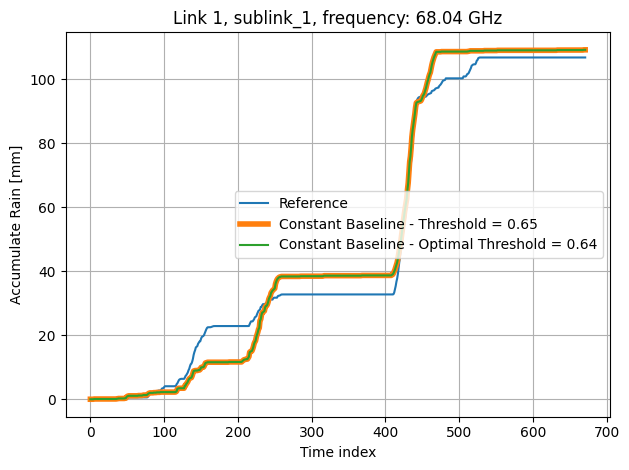

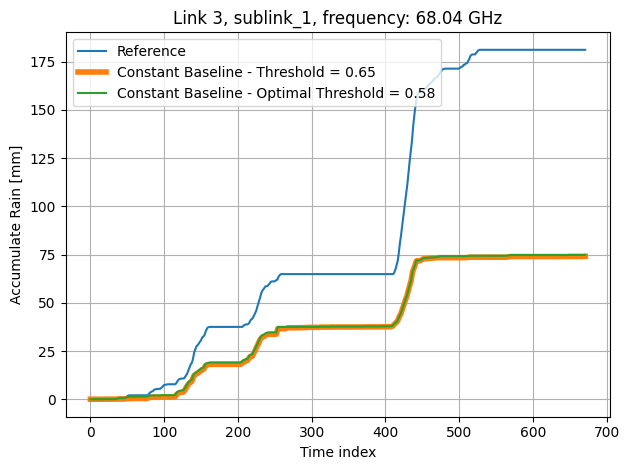

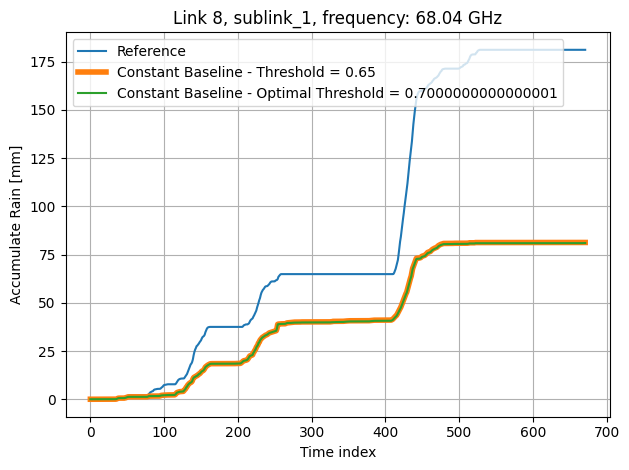

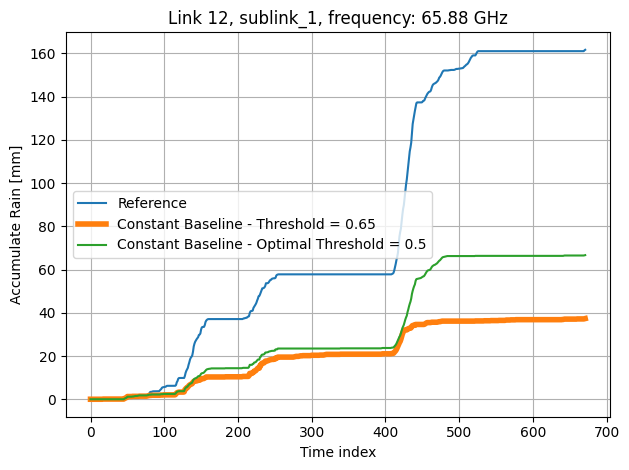

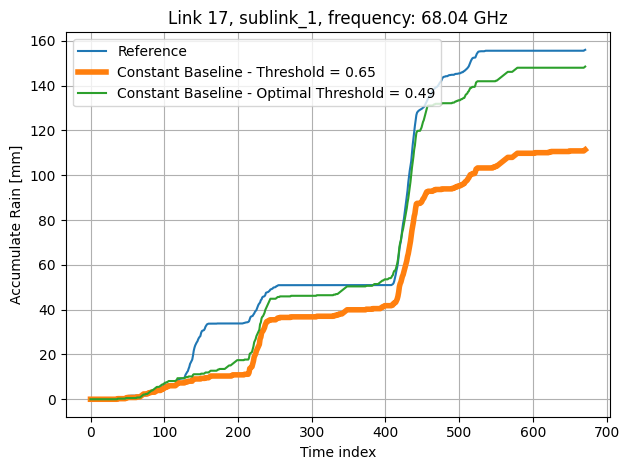

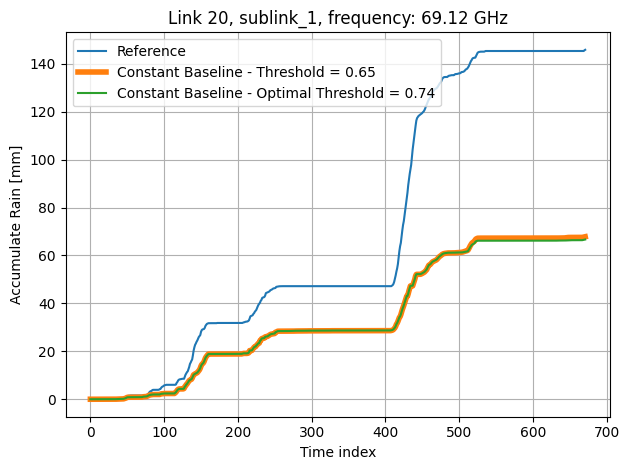

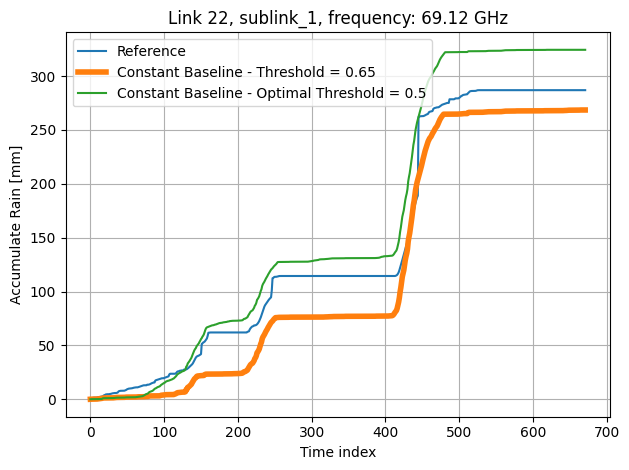

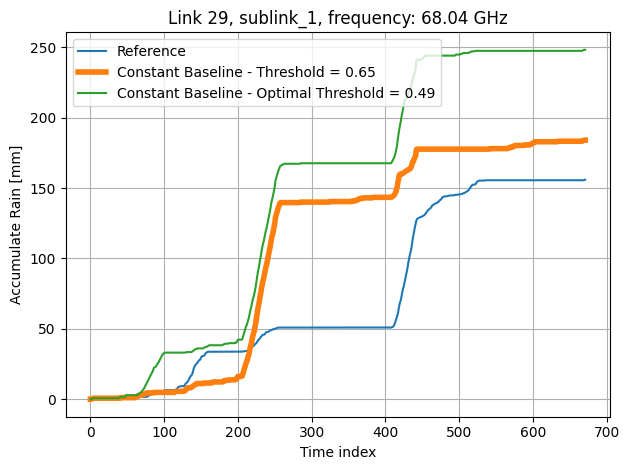

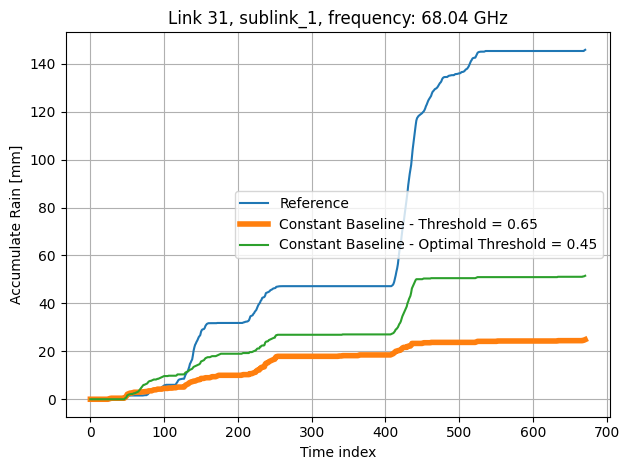

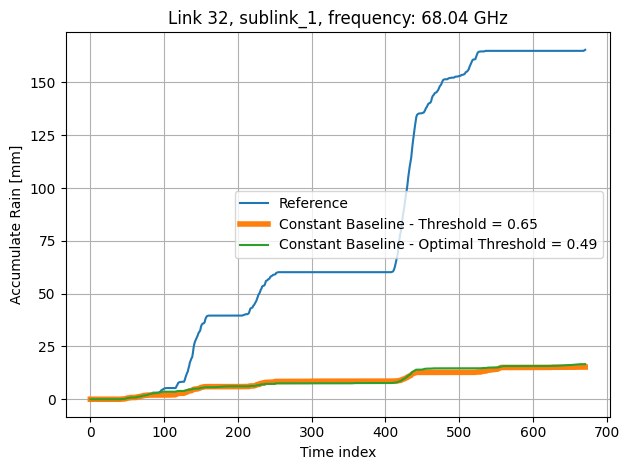

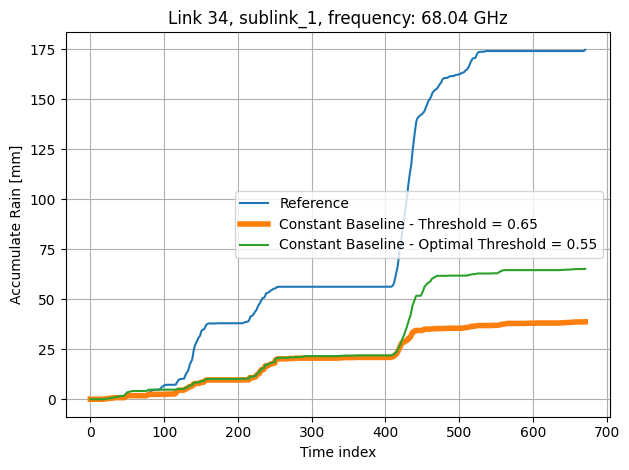

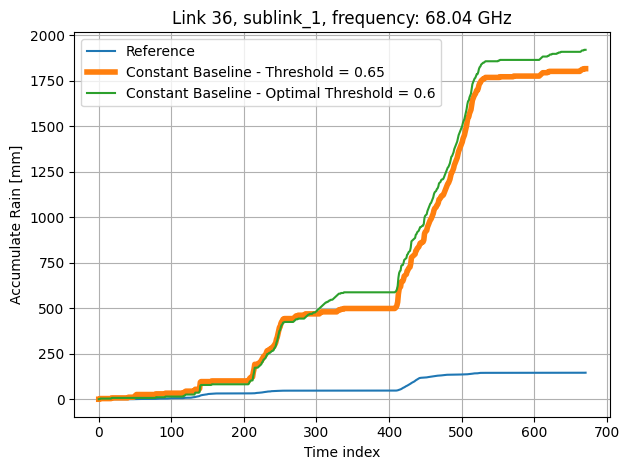

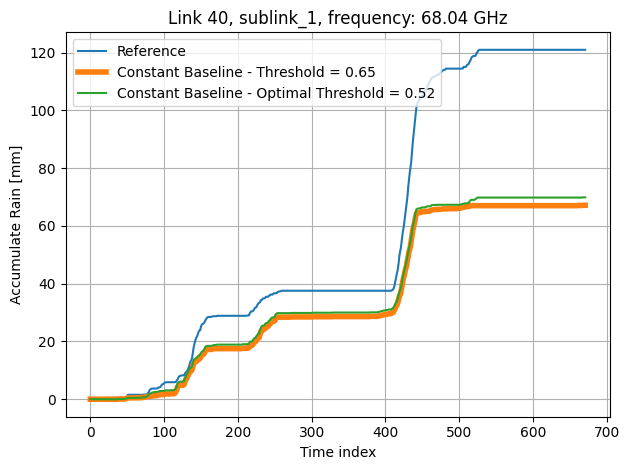

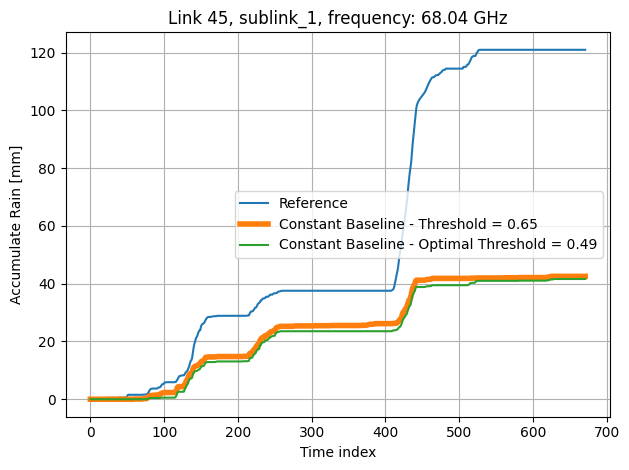

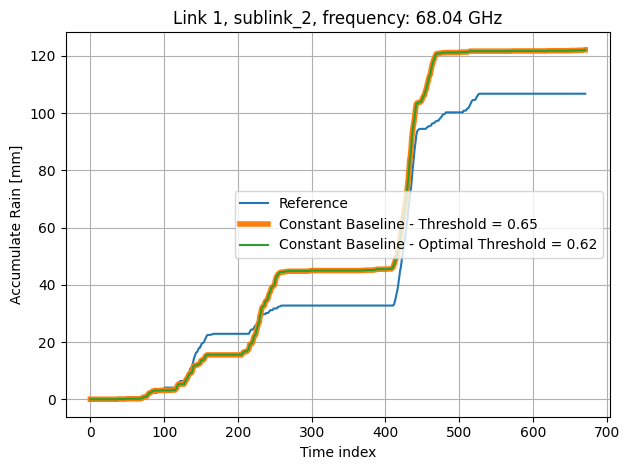

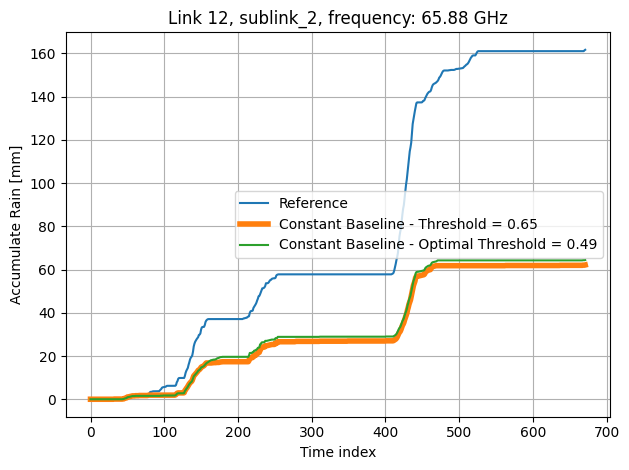

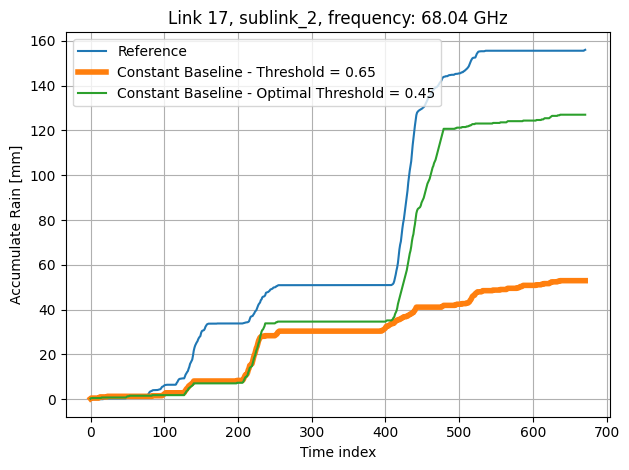

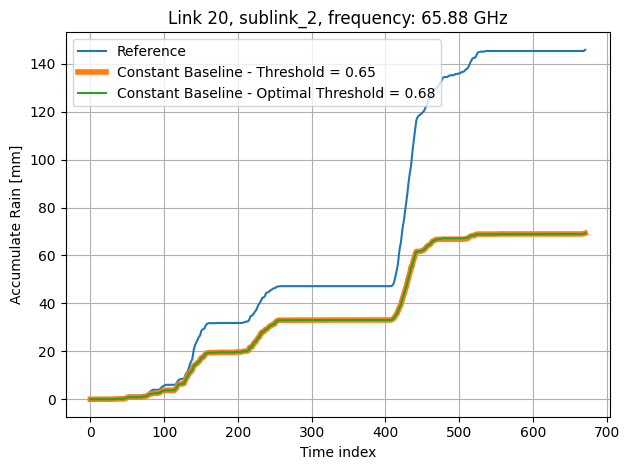

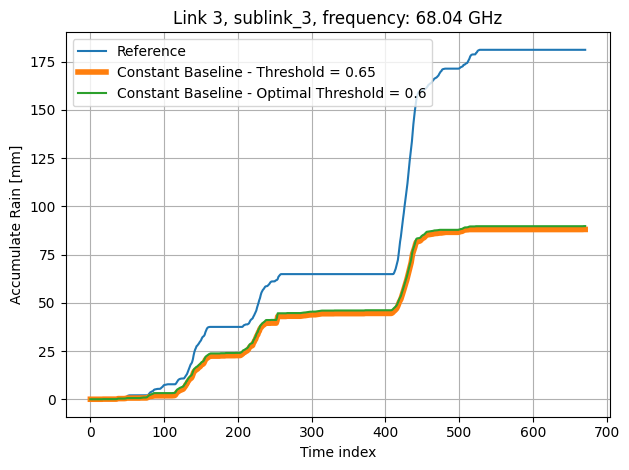

In [48]:
links = [i for i in range(0, len(HF_sliced))]
statistics_window_size=15
statistics_wet_dry_threshold=0.65
r_min=0.01

tsc65 = pnc.scm.rain_estimation.two_step_constant_baseline(pnc.scm.power_law.PowerLawType.MAX, r_min,
                                                         statistics_window_size, statistics_wet_dry_threshold,
                                                         wa_factor=1.2)
for link_id in links:
    tscT = pnc.scm.rain_estimation.two_step_constant_baseline(pnc.scm.power_law.PowerLawType.MAX, r_min,
                                                         statistics_window_size, threshold_list[link_id],
                                                         wa_factor=1.2)
    ref_data = gaugetime_5to15(HF_sliced.get_link(link_id))
    rain_ts65, wd65, ts_baseline_res65 = tsc65(HF_sliced.get_link(link_id).attenuation(),
                                    HF_sliced.get_link(link_id).meta_data)
    rain_ts, wd, ts_baseline_res = tscT(HF_sliced.get_link(link_id).attenuation(),
                                    HF_sliced.get_link(link_id).meta_data)
    
    
    
    plt.plot(np.nancumsum(ref_data), label="Reference")
    plt.plot(np.nancumsum(rain_ts65), label="Constant Baseline - Threshold = 0.65", linewidth=4)
    plt.plot(np.nancumsum(rain_ts), label=f"Constant Baseline - Optimal Threshold = {threshold_list[link_id]}")
    plt.title(f'Link {HF_sliced.get_link(link_id).meta_data.cml_id}, {HF_sliced.get_link(link_id).meta_data.sublink_id}, frequency: {HF_sliced.get_link(link_id).meta_data.frequency} GHz')
    plt.xlabel("Time index")
    plt.ylabel("Accumulate Rain [mm]")
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

In [44]:
# Check bad indexes
low = [1, 2, 3, 5, 8, 9, 10, 12, 13, 15, 17, 18]
high = [7, 11]
success = [0, 4, 6, 14, 15]

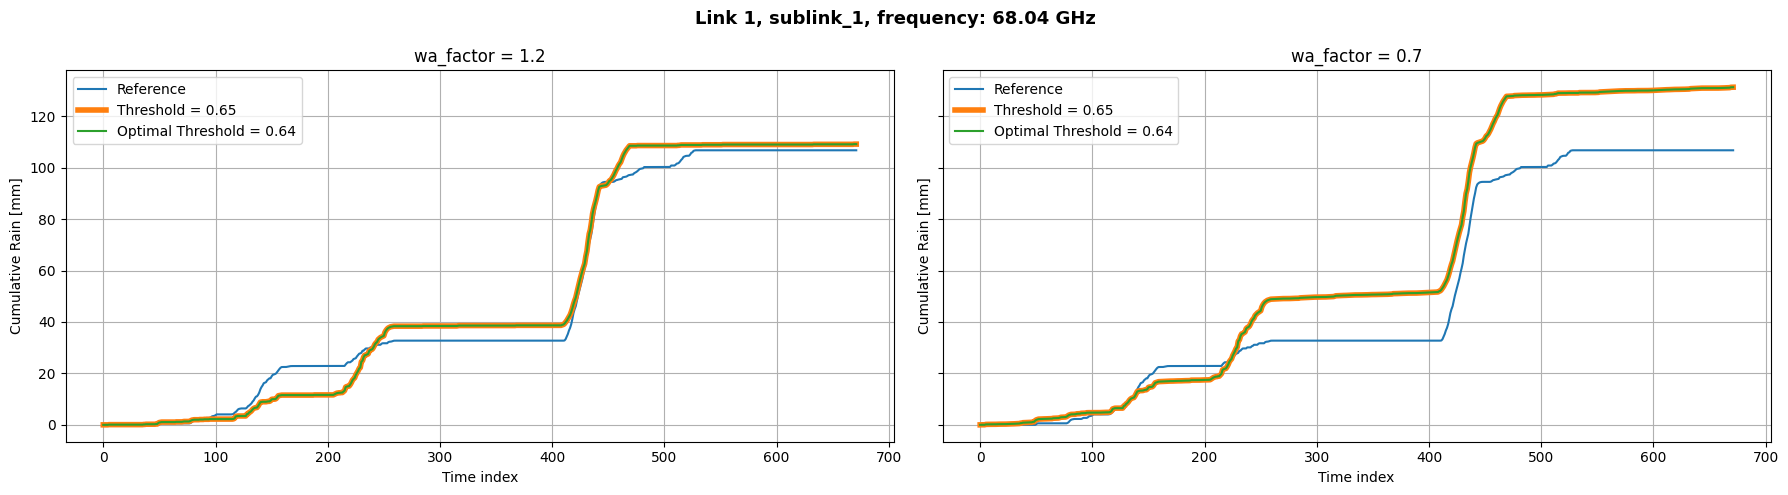

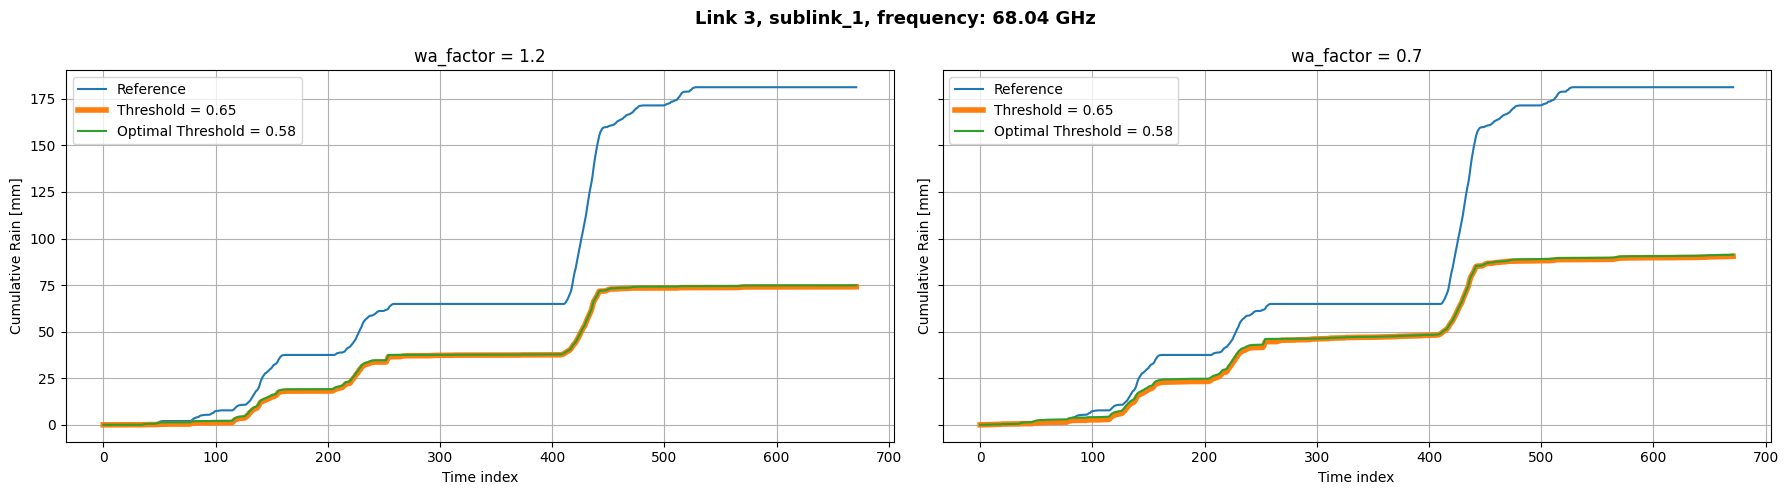

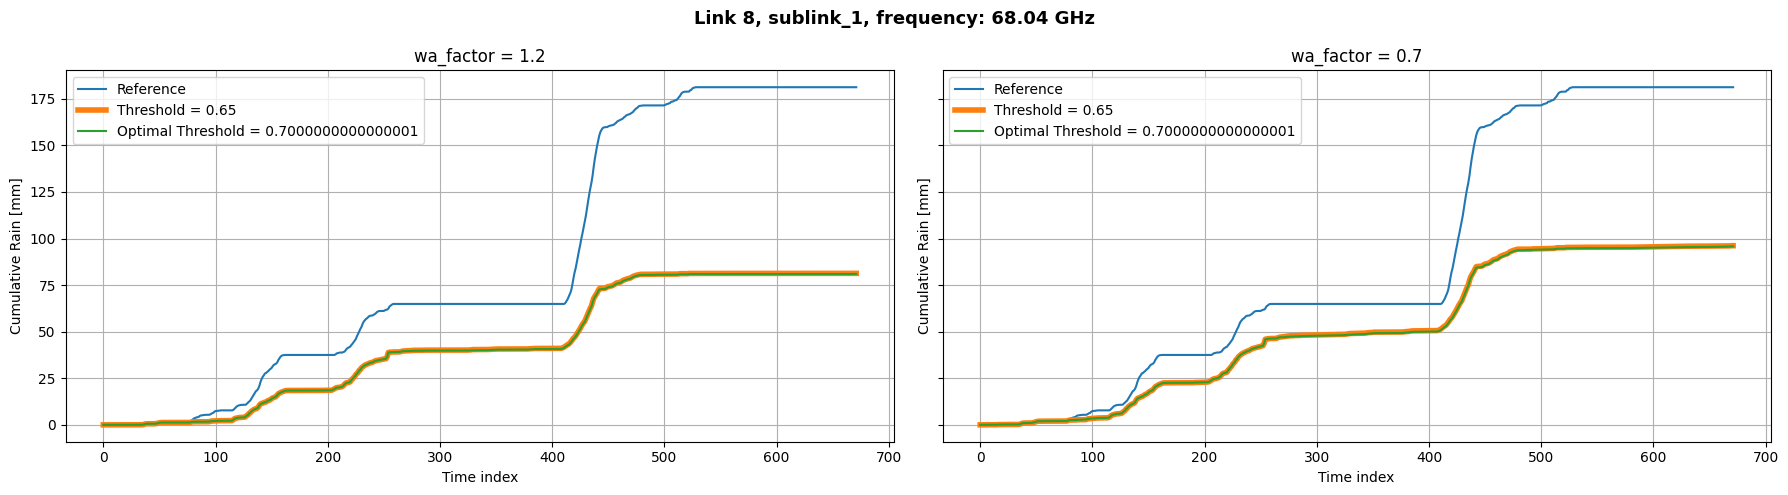

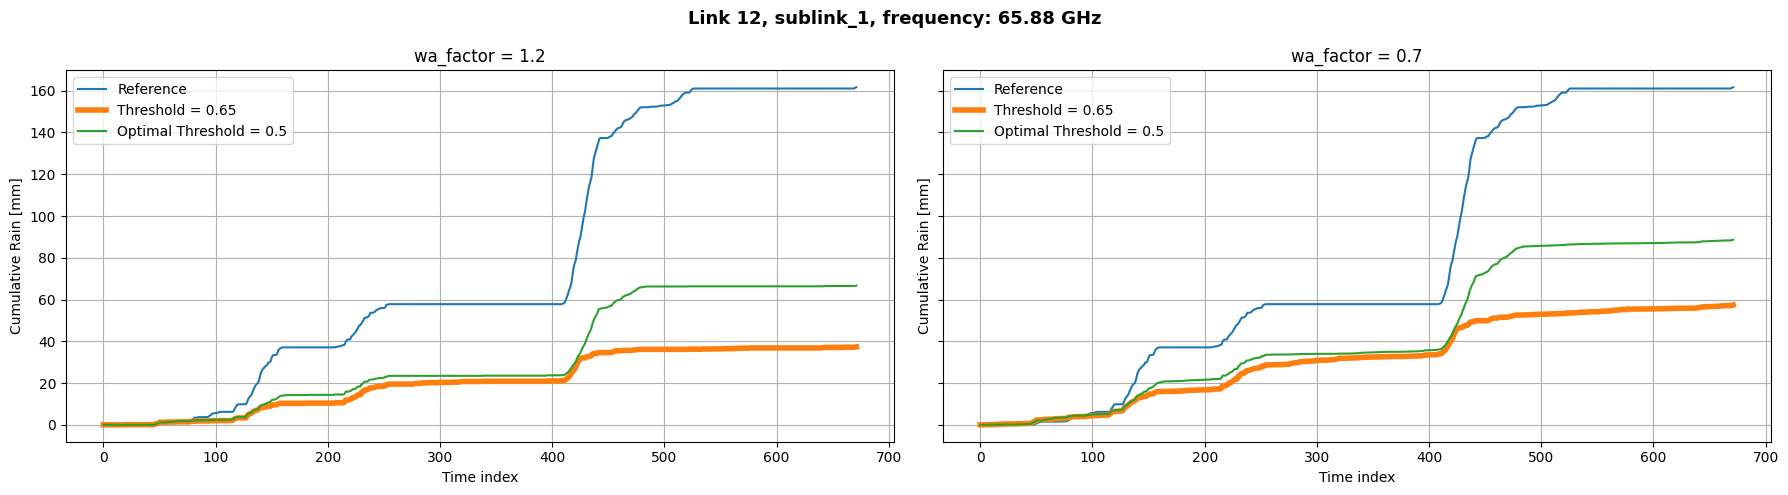

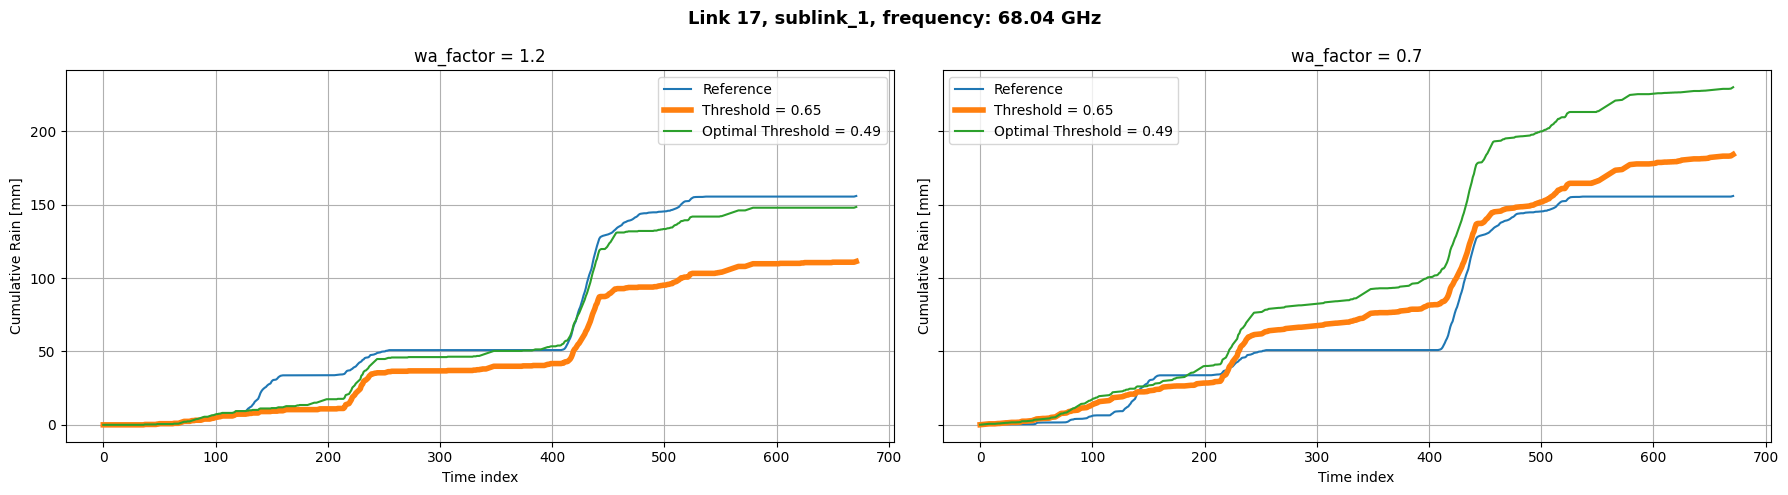

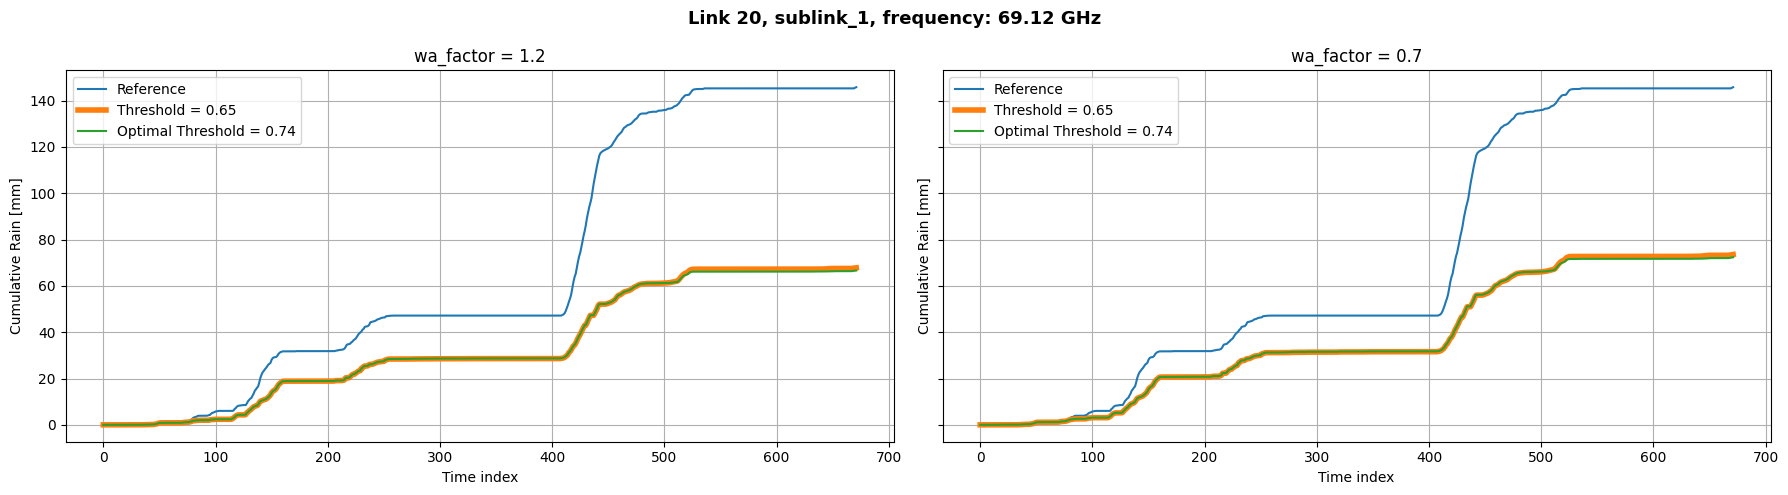

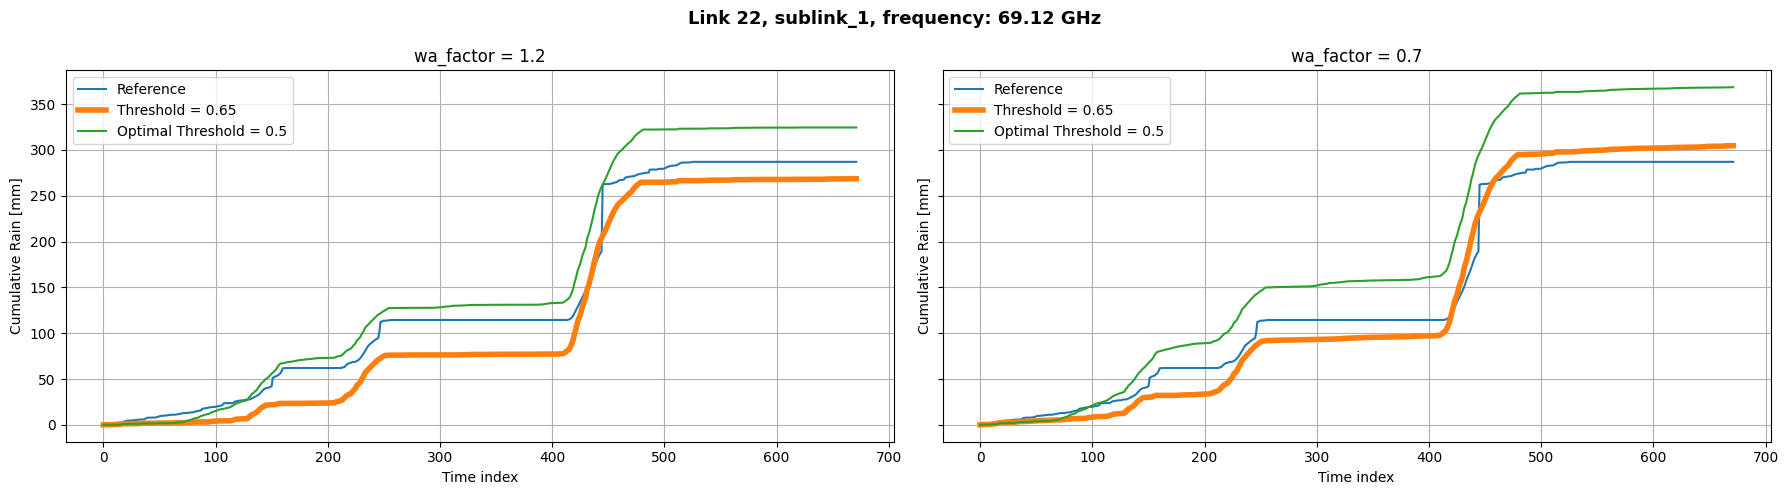

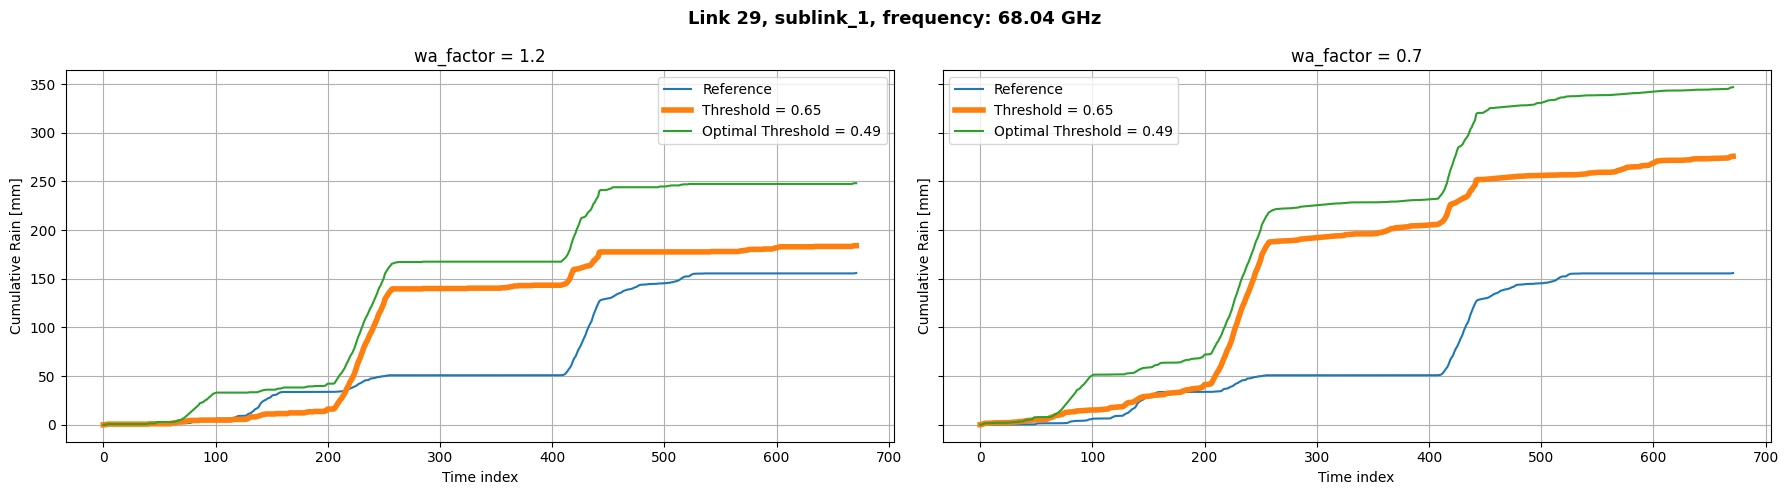

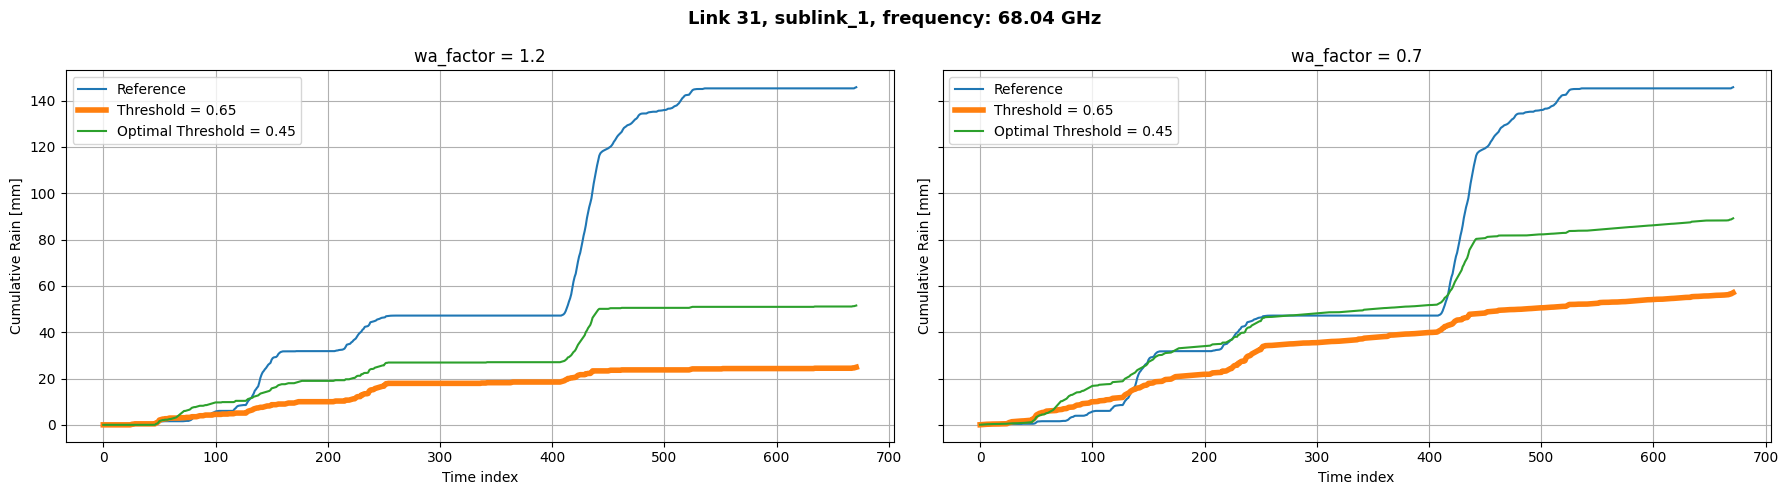

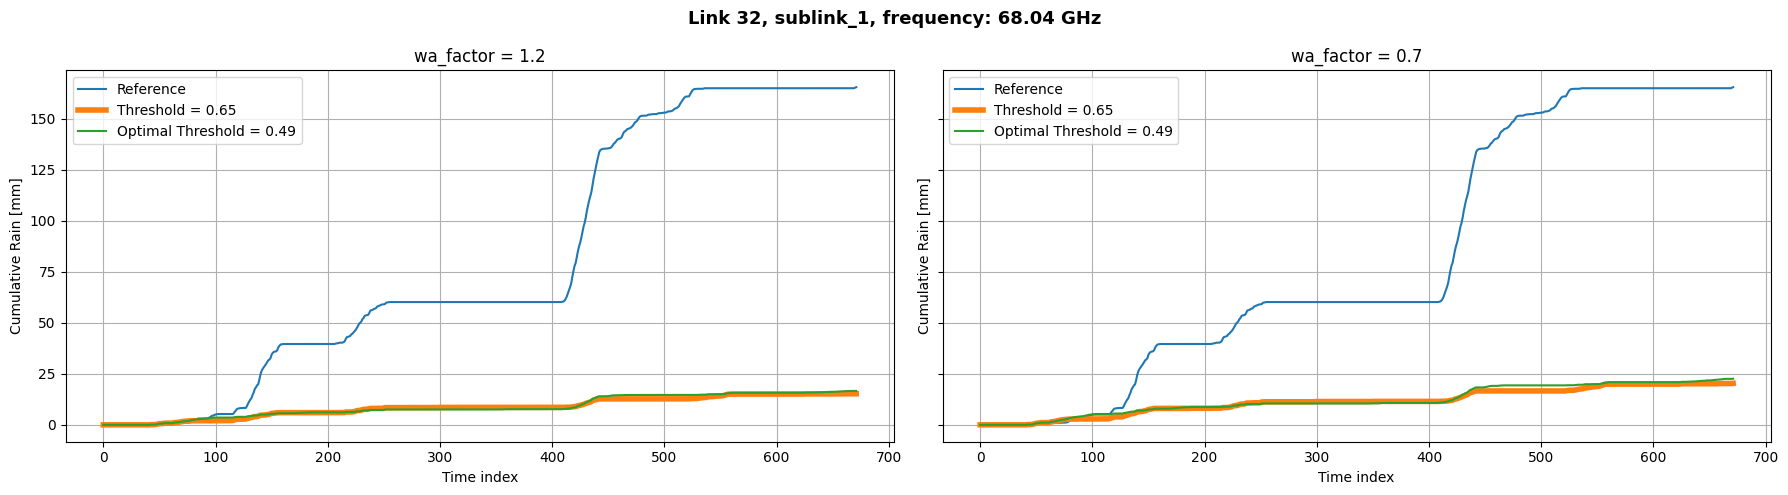

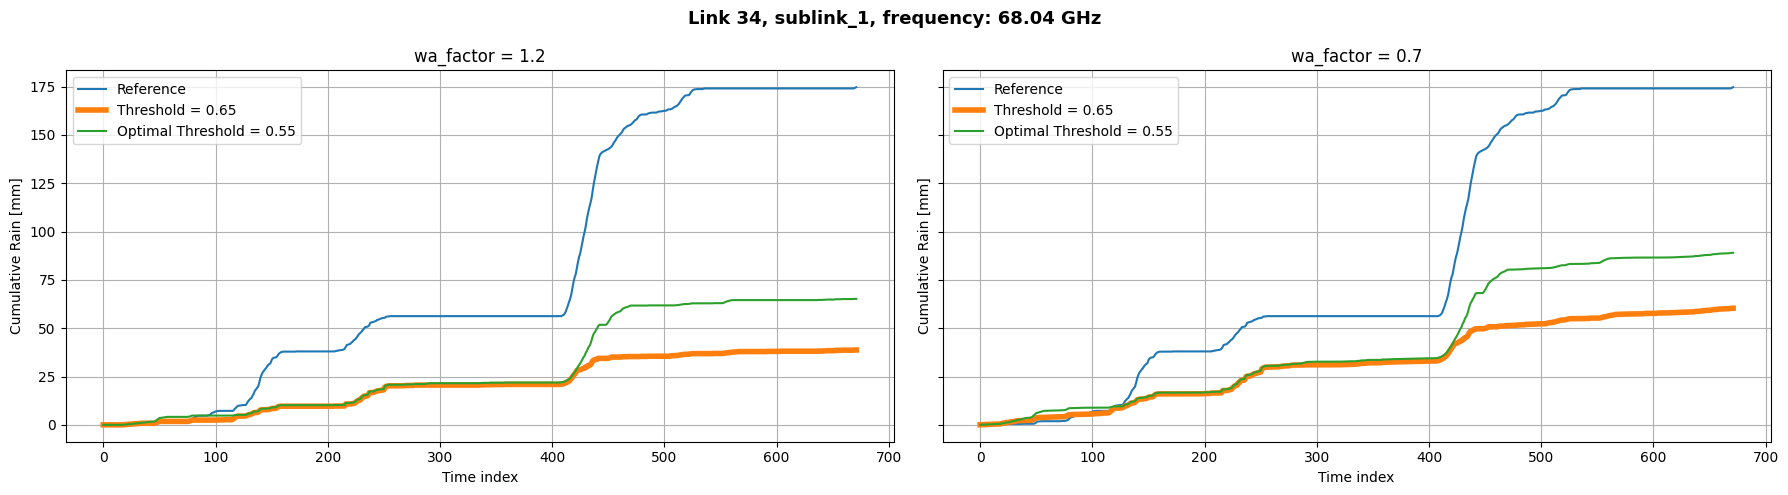

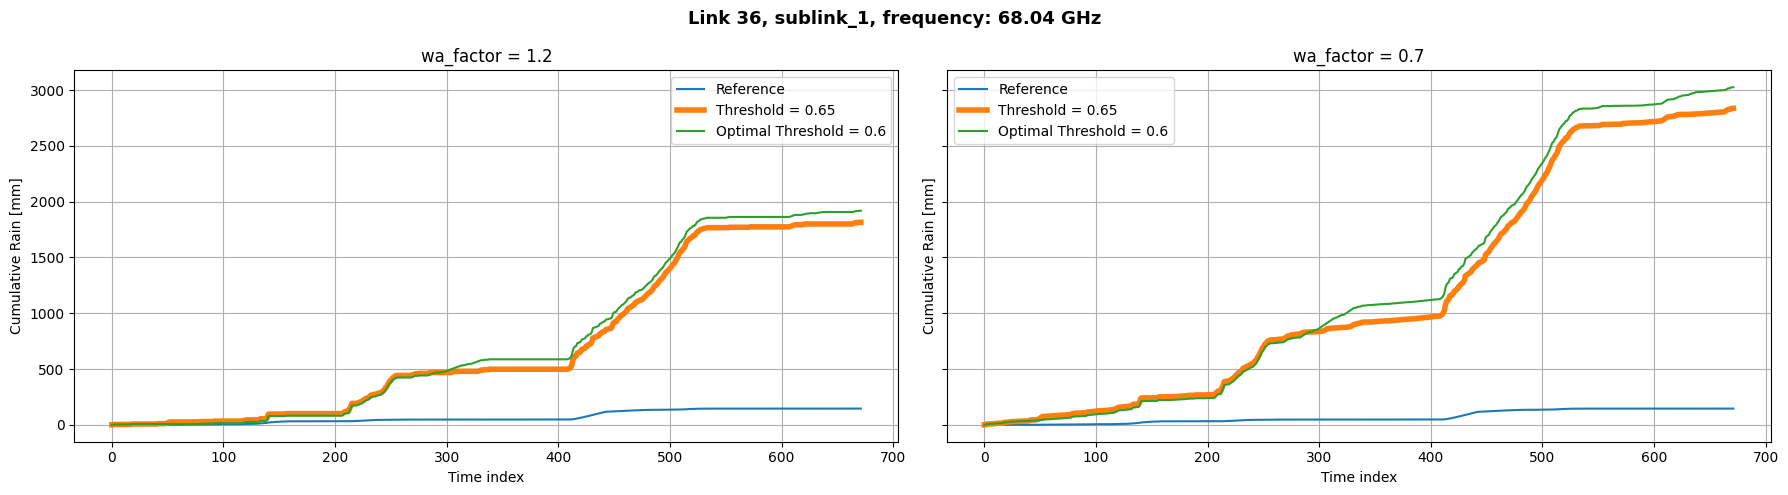

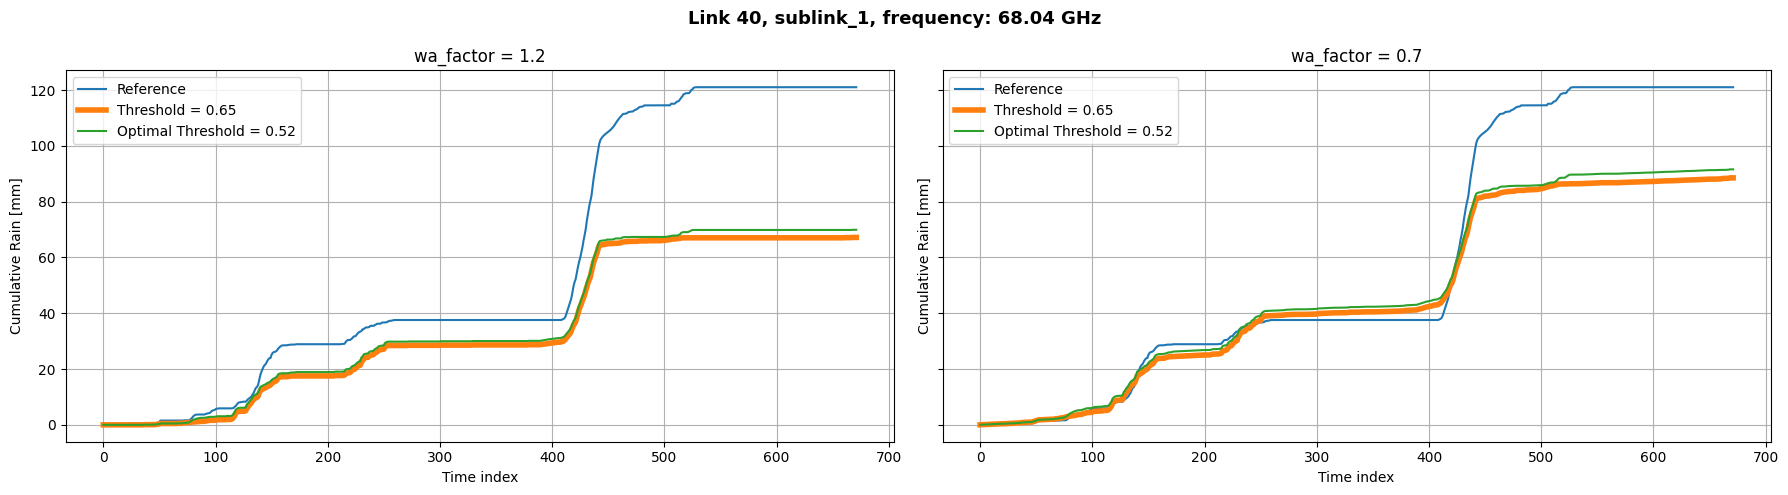

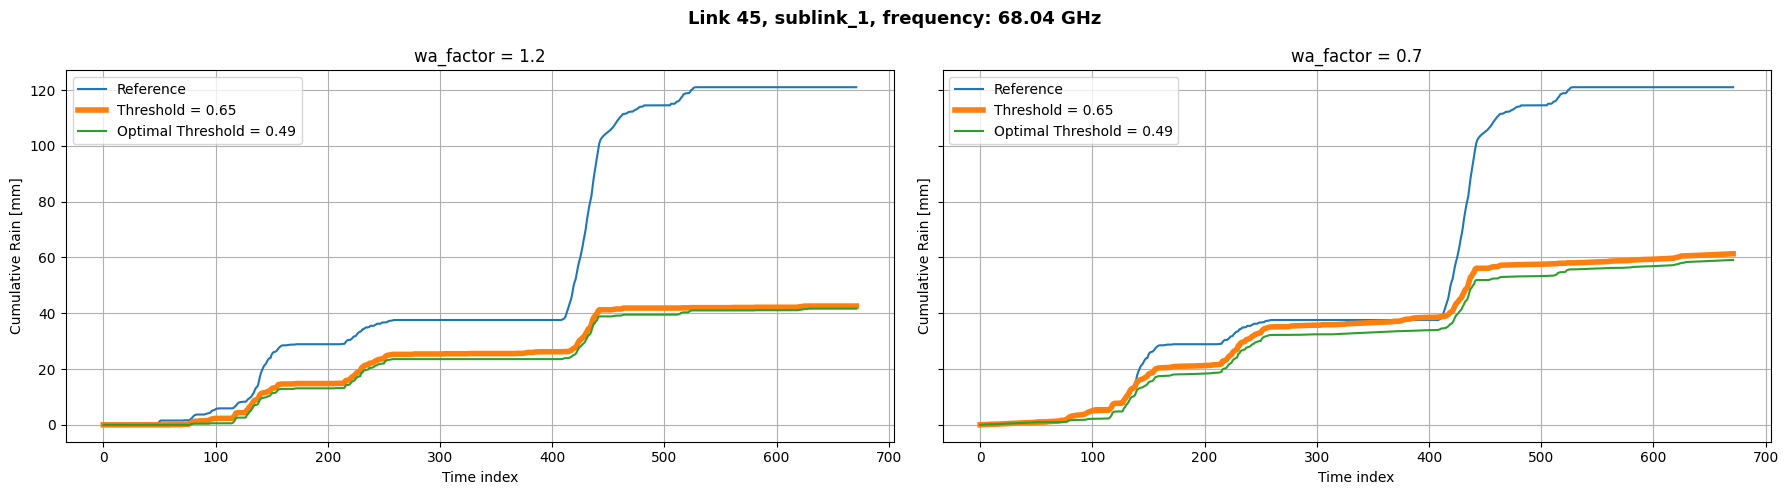

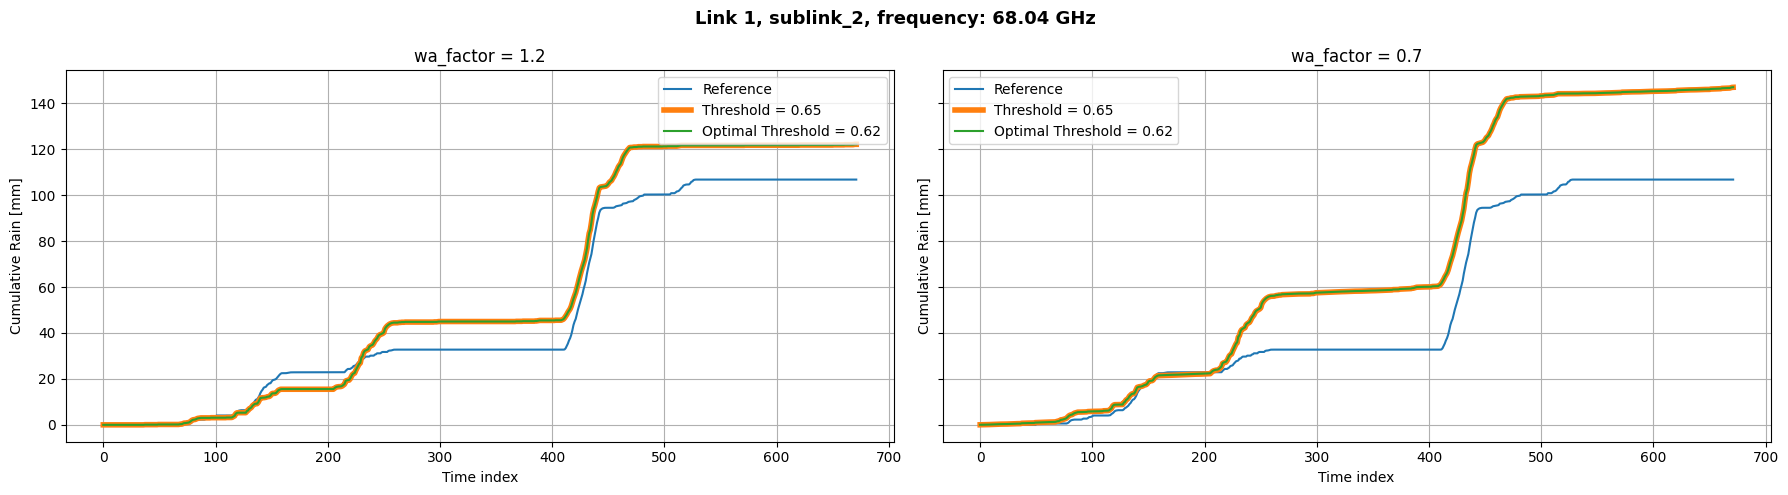

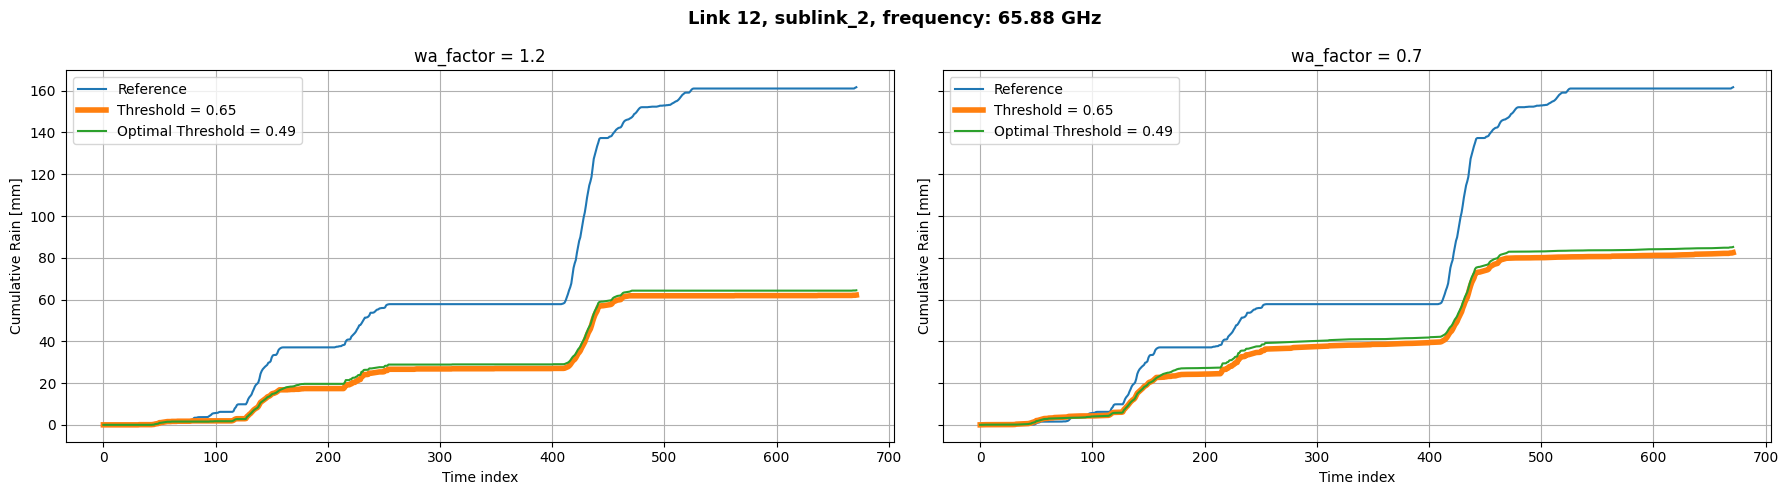

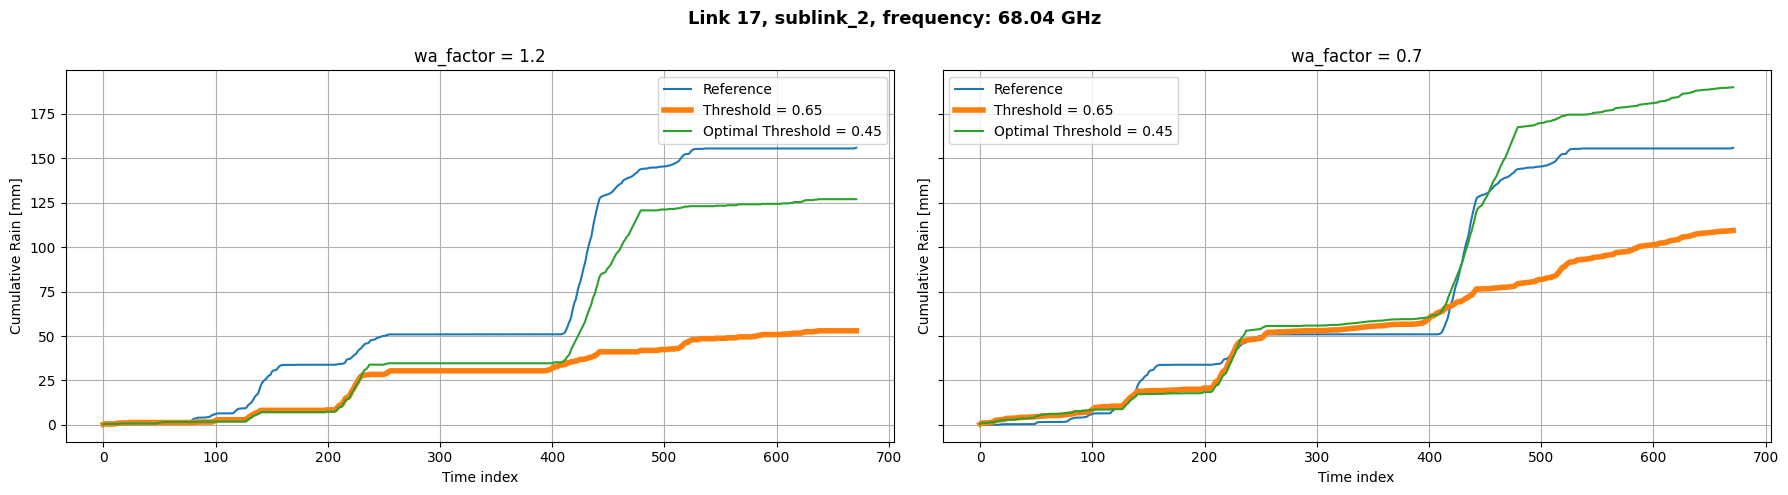

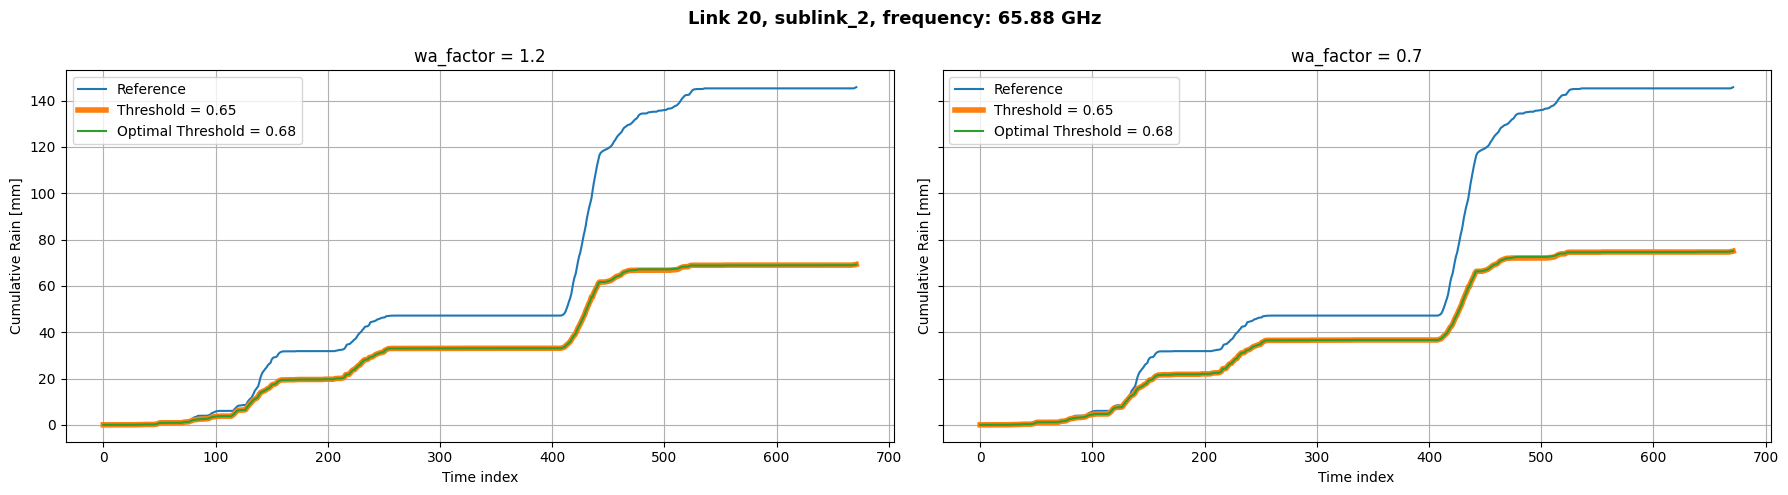

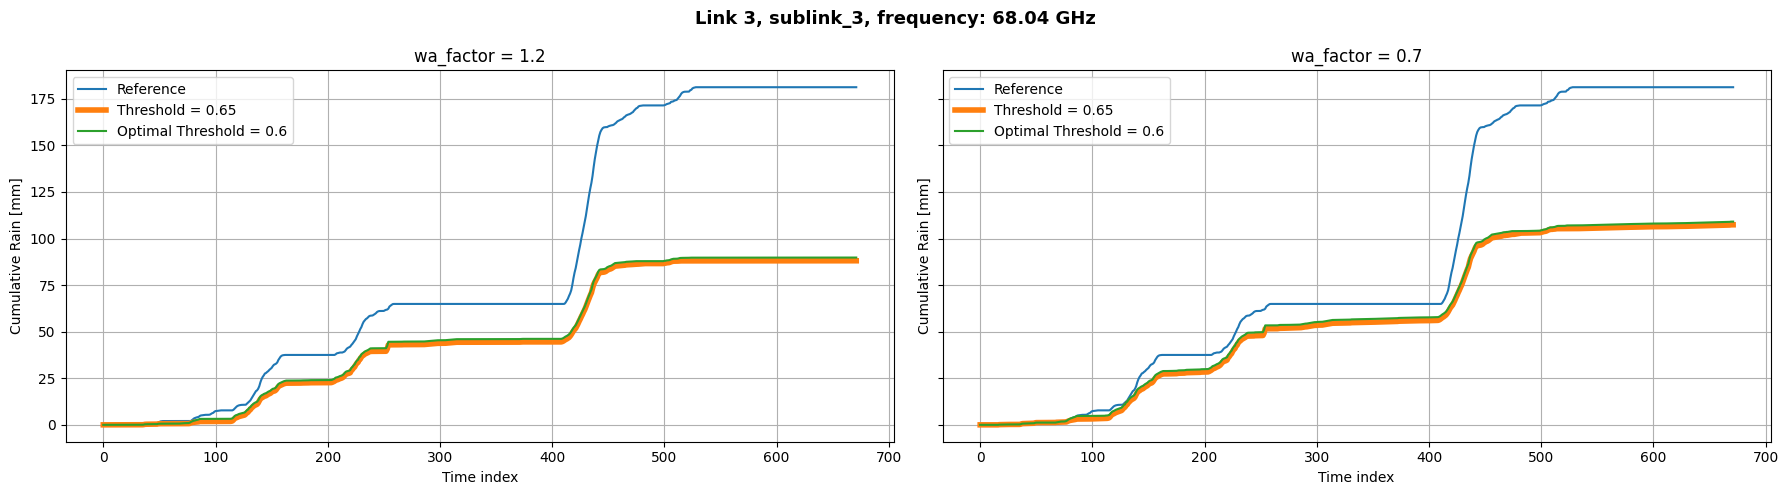

In [49]:
links = [i for i in range(0, len(HF_sliced))]
statistics_window_size = 15
statistics_wet_dry_threshold = 0.65
r_min = 0.01
wa_factors = [1.2, 0.7]

tsc65 = {
    wa: pnc.scm.rain_estimation.two_step_constant_baseline(
        pnc.scm.power_law.PowerLawType.MAX, r_min,
        statistics_window_size, statistics_wet_dry_threshold,
        wa_factor=wa)
    for wa in wa_factors
}

for link_id in links:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

    for ax, wa in zip(axes, wa_factors):
        tscT = pnc.scm.rain_estimation.two_step_constant_baseline(
            pnc.scm.power_law.PowerLawType.MAX, r_min,
            statistics_window_size, threshold_list[link_id],
            wa_factor=wa)

        ref_data = gaugetime_5to15(HF_sliced.get_link(link_id))
        rain_ts65, _, _ = tsc65[wa](HF_sliced.get_link(link_id).attenuation(),
                                    HF_sliced.get_link(link_id).meta_data)
        rain_ts, _, _   = tscT(HF_sliced.get_link(link_id).attenuation(),
                                HF_sliced.get_link(link_id).meta_data)

        ax.plot(np.nancumsum(ref_data), label="Reference")
        ax.plot(np.nancumsum(rain_ts65), label="Threshold = 0.65", linewidth=4)
        ax.plot(np.nancumsum(rain_ts), label=f"Optimal Threshold = {threshold_list[link_id]}")
        ax.set_title(f"wa_factor = {wa}")
        ax.set_xlabel("Time index")
        ax.set_ylabel("Cumulative Rain [mm]")
        ax.grid()
        ax.legend()

    fig.suptitle(
        f'Link {HF_sliced.get_link(link_id).meta_data.cml_id}, '
        f'{HF_sliced.get_link(link_id).meta_data.sublink_id}, '
        f'frequency: {HF_sliced.get_link(link_id).meta_data.frequency} GHz',
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

In [45]:
def countnan(link, r_min, statistics_window_size, statistics_wet_dry_threshold, wa_factor):
    tsc = pnc.scm.rain_estimation.two_step_constant_baseline(
        pnc.scm.power_law.PowerLawType.MAX, r_min,
        statistics_window_size, statistics_wet_dry_threshold,
        wa_factor=wa_factor
    )

    att = link.attenuation()
    rain_ts, wd, ts_baseline_res = tsc(att, link.meta_data)

    rain_ts         = np.asarray(rain_ts).squeeze()
    wd              = np.asarray(wd).squeeze()
    ts_baseline_res = np.asarray(ts_baseline_res).squeeze()

    results = {}
    for name, arr in [("rain_ts", rain_ts), ("wd", wd), ("ts_baseline_res", ts_baseline_res)]:
        nan_count = int(np.sum(np.isnan(arr)))
        print(f"[{name}]  length={len(arr)}  NaNs={nan_count}  ({nan_count/len(arr):.1%})")
        results[name] = {"array": arr, "nan_count": nan_count, "nan_mask": np.isnan(arr)}

    return results

In [46]:
for id in low:
    print('The link id is: '+ str(id) +' and the threshold is: '+str(threshold_list[id]))
    countnan(HF_sliced.get_link(id), 0.01, 15, threshold_list[id], 1.2)
    print("\n")

The link id is: 1 and the threshold is: 0.58
[rain_ts]  length=672  NaNs=0  (0.0%)
[wd]  length=672  NaNs=0  (0.0%)
[ts_baseline_res]  length=672  NaNs=0  (0.0%)


The link id is: 2 and the threshold is: 0.7000000000000001
[rain_ts]  length=672  NaNs=0  (0.0%)
[wd]  length=672  NaNs=0  (0.0%)
[ts_baseline_res]  length=672  NaNs=0  (0.0%)


The link id is: 3 and the threshold is: 0.5
[rain_ts]  length=672  NaNs=0  (0.0%)
[wd]  length=672  NaNs=0  (0.0%)
[ts_baseline_res]  length=672  NaNs=0  (0.0%)


The link id is: 5 and the threshold is: 0.74
[rain_ts]  length=672  NaNs=4  (0.6%)
[wd]  length=672  NaNs=22  (3.3%)
[ts_baseline_res]  length=672  NaNs=0  (0.0%)


The link id is: 8 and the threshold is: 0.45
[rain_ts]  length=672  NaNs=1  (0.1%)
[wd]  length=672  NaNs=15  (2.2%)
[ts_baseline_res]  length=672  NaNs=0  (0.0%)


The link id is: 9 and the threshold is: 0.49
[rain_ts]  length=672  NaNs=1  (0.1%)
[wd]  length=672  NaNs=15  (2.2%)
[ts_baseline_res]  length=672  NaNs=0  (0.0%)




In [47]:
with_nan = [5, 8, 9, 10, 17]

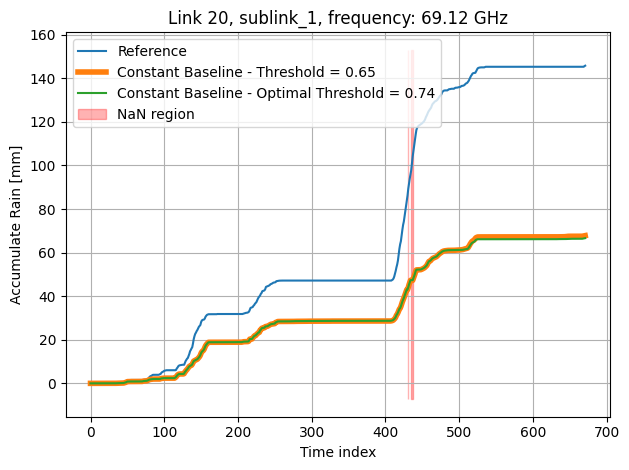

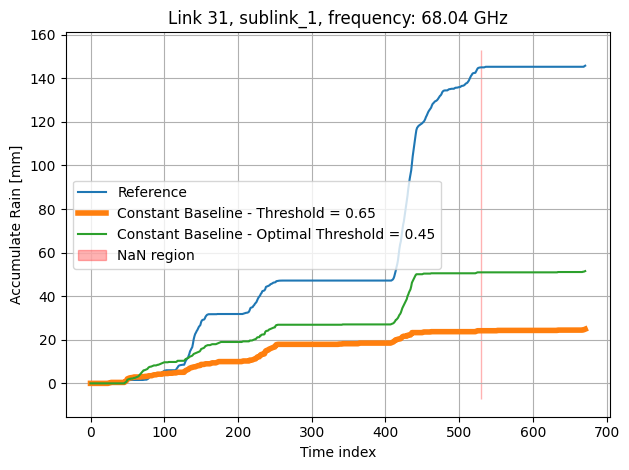

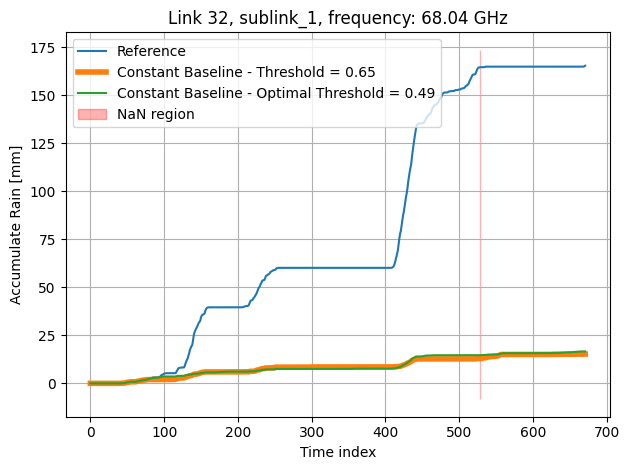

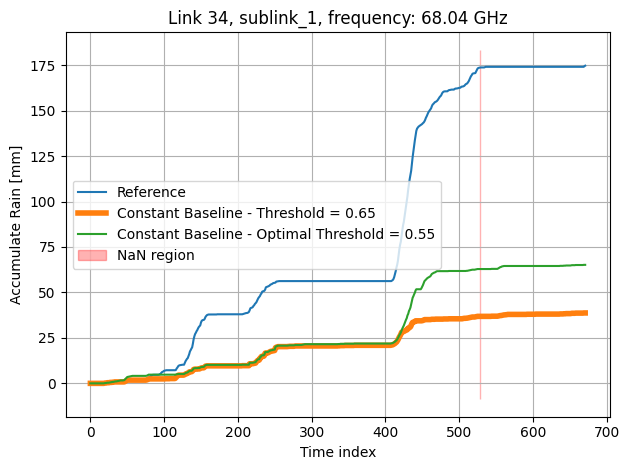

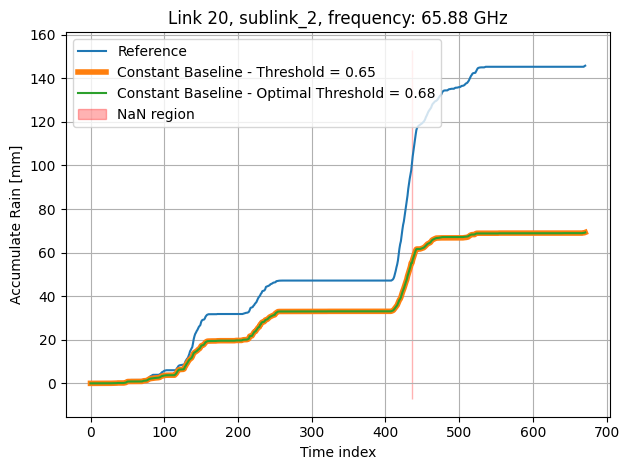

In [48]:
r_min = 0.01
statistics_window_size=15 
statistics_wet_dry_threshold=0.65
wa_factor=1.2


tsc65 = pnc.scm.rain_estimation.two_step_constant_baseline(pnc.scm.power_law.PowerLawType.MAX, r_min,
                                                         statistics_window_size, statistics_wet_dry_threshold,
                                                         wa_factor)
for link_id in with_nan:
    tscT = pnc.scm.rain_estimation.two_step_constant_baseline(pnc.scm.power_law.PowerLawType.MAX, r_min,
                                                         statistics_window_size, threshold_list[link_id],
                                                         wa_factor)
    ref_data = gaugetime_5to15(HF_sliced.get_link(link_id))
    rain_ts65, wd65, ts_baseline_res65 = tsc65(HF_sliced.get_link(link_id).attenuation(),
                                    HF_sliced.get_link(link_id).meta_data)
    rain_ts, wd, ts_baseline_res = tscT(HF_sliced.get_link(link_id).attenuation(),
                                    HF_sliced.get_link(link_id).meta_data)

    # --- NaN detection ---
    rain_ts_arr  = np.asarray(rain_ts).squeeze()
    ts_base_arr  = np.asarray(ts_baseline_res).squeeze()
    time         = np.arange(len(rain_ts_arr))

    nan_mask_rain = np.isnan(rain_ts_arr)
    nan_mask_base = np.isnan(ts_base_arr)
    nan_mask_any  = nan_mask_rain | nan_mask_base   # union: NaN in either array

    # --- Plot ---
    plt.plot(np.nancumsum(ref_data), label="Reference")
    plt.plot(np.nancumsum(rain_ts65), label="Constant Baseline - Threshold = 0.65", linewidth=4)
    plt.plot(np.nancumsum(rain_ts), label=f"Constant Baseline - Optimal Threshold = {threshold_list[link_id]}")

    # Shade NaN regions
    if nan_mask_any.any():
        plt.fill_between(time, plt.ylim()[0], plt.ylim()[1],
                         where=nan_mask_any, color="red", alpha=0.3, label="NaN region")
    
    plt.title(f'Link {HF_sliced.get_link(link_id).meta_data.cml_id}, '
              f'{HF_sliced.get_link(link_id).meta_data.sublink_id}, '
              f'frequency: {HF_sliced.get_link(link_id).meta_data.frequency} GHz')
    plt.xlabel("Time index")
    plt.ylabel("Accumulate Rain [mm]")
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

In [49]:
valid_links = []

for link_id in range(len(HF_sliced)):
    att = np.asarray(HF_sliced.get_link(link_id).attenuation()).squeeze()
    nan_count = int(np.sum(np.isnan(att)))
    if nan_count == 0:
        valid_links.append(link_id)

print(f"Links without NaNs in attenuation: {len(valid_links)} / {len(HF_sliced)}")
print(f"Valid link indexes: {valid_links}")

Links without NaNs in attenuation: 14 / 19
Valid link indexes: [0, 1, 2, 3, 4, 6, 7, 11, 12, 13, 14, 15, 16, 18]


In [ ]:
noNanSet = keep_links(valid_links)

36 0.8


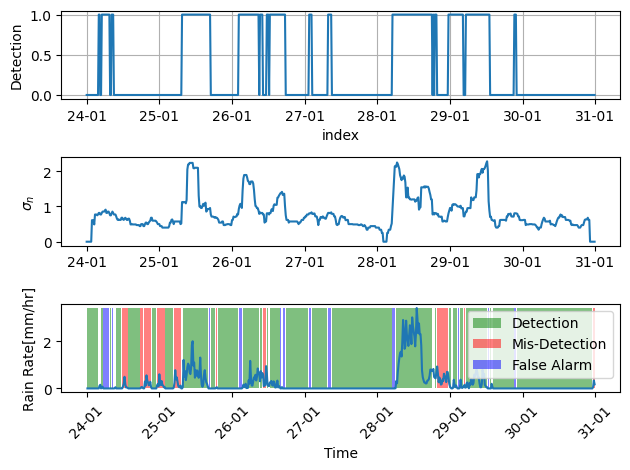

Accuracy:  80.2%
Precision: 77.4%
Recall:    69.0%


{'TPR': np.float64(0.689922480620155), 'FPR': np.float64(0.12590799031476999)}

In [44]:
print(HF_sliced.get_link(11).meta_data.cml_id, 0.8)
classification_plot(HF_sliced.get_link(11), 0.8, 15, True, True)


In [20]:
def roc_threshold_15(link, window, is_minmax, step, plot=True):
    # Array of thresholds
    thresholds = np.arange(0.2, 1.51, step)

    # Get TPR and FPR for every threshold
    TPRs = [classification_plot(link, t, window, is_minmax=True, plot=False)['TPR'] for t in thresholds]
    FPRs = [classification_plot(link, t, window, is_minmax=True, plot=False)['FPR'] for t in thresholds]

    if plot: # will plot ROC curve

        plt.figure(figsize=(8, 6))

        # Plot the ROC Curve
        plt.plot(FPRs, TPRs, color='blue', lw=2, label=f'ROC Curve ({link.meta_data.cml_id}, {link.meta_data.sublink_id} Std)')

        # Plot the "Random Guess" line
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance')

        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate (FPR)')
        plt.ylabel('True Positive Rate (TPR)')
        plt.title('ROC Curve for Rain Detection')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.show()

    fpr_arr = np.array(FPRs)
    tpr_arr = np.array(TPRs)
    thresh_arr = np.array(thresholds)

    # Calculate distance to the "Perfect" point (0, 1)
    # Distance = sqrt( FPR^2 + (1-TPR)^2 )
    distances = np.sqrt(fpr_arr**2 + (1 - tpr_arr)**2)

    # Find candidates with TPR >= 0.8
    high_tpr_mask = tpr_arr >= 0.8

    if np.any(high_tpr_mask):
        # Use minimum distance among high-TPR candidates
        masked_distances = np.where(high_tpr_mask, distances, np.nan)
        best_idx = np.nanargmin(masked_distances)
    else:
        # Fall back: first index where TPR >= 0.85
        tpr_85_mask = tpr_arr >= 0.80
        if np.any(tpr_85_mask):
            best_idx = np.argmax(tpr_85_mask)  # argmax returns first True index
        else:
            best_idx = np.nanargmin(distances)  # last resort fallback

    bestT = {"Best Threshold": float(thresh_arr[best_idx]), "Resulting TPR": float(tpr_arr[best_idx]), "Resulting FPR": float(fpr_arr[best_idx])}

    return bestT


Accuracy:  40.2%
Precision: 39.1%
Recall:    98.8%
Accuracy:  40.2%
Precision: 39.1%
Recall:    98.8%
Accuracy:  40.2%
Precision: 39.1%
Recall:    98.8%
Accuracy:  40.2%
Precision: 39.1%
Recall:    98.8%
Accuracy:  40.2%
Precision: 39.1%
Recall:    98.8%
Accuracy:  40.8%
Precision: 39.3%
Recall:    98.8%
Accuracy:  40.8%
Precision: 39.3%
Recall:    98.8%
Accuracy:  40.8%
Precision: 39.3%
Recall:    98.8%
Accuracy:  40.8%
Precision: 39.3%
Recall:    98.8%
Accuracy:  40.8%
Precision: 39.3%
Recall:    98.8%
Accuracy:  40.8%
Precision: 39.3%
Recall:    98.8%
Accuracy:  40.8%
Precision: 39.3%
Recall:    98.8%
Accuracy:  40.8%
Precision: 39.3%
Recall:    98.8%
Accuracy:  40.8%
Precision: 39.3%
Recall:    98.8%
Accuracy:  42.1%
Precision: 39.8%
Recall:    98.8%
Accuracy:  42.1%
Precision: 39.8%
Recall:    98.8%
Accuracy:  42.1%
Precision: 39.8%
Recall:    98.8%
Accuracy:  42.1%
Precision: 39.8%
Recall:    98.8%
Accuracy:  42.1%
Precision: 39.8%
Recall:    98.8%
Accuracy:  42.1%
Precision: 39.

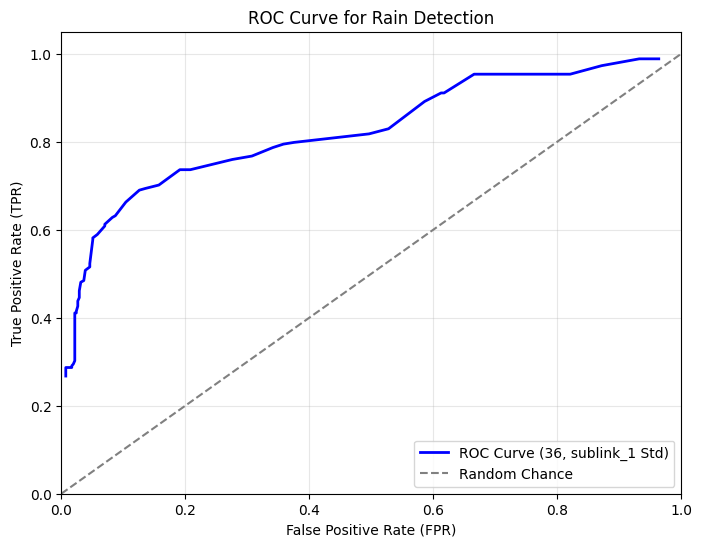

{'Best Threshold': 0.6000000000000003,
 'Resulting TPR': 0.8178294573643411,
 'Resulting FPR': 0.4963680387409201}

In [36]:
roc_threshold_15(HF_sliced.get_link(11), 15, True, 0.01, plot=True)

In [45]:
tsc100 = pnc.scm.rain_estimation.two_step_constant_baseline(pnc.scm.power_law.PowerLawType.MAX, 0.01,
                                                         15, 1,
                                                         1.2)

tsc80 = pnc.scm.rain_estimation.two_step_constant_baseline(pnc.scm.power_law.PowerLawType.MAX, 0.01,
                                                         15, 0.8,
                                                         1.2)
tsc60 = pnc.scm.rain_estimation.two_step_constant_baseline(pnc.scm.power_law.PowerLawType.MAX, 0.01,
                                                         15, 0.6,
                                                         1.2)
att = HF_sliced.get_link(11).attenuation()
rain_ts100, wd100, ts_baseline_res100 = tsc100(att,
                                HF_sliced.get_link(11).meta_data)
rain_ts80, wd80, ts_baseline_res80 = tsc80(att,
                                HF_sliced.get_link(11).meta_data)
rain_ts60, wd60, ts_baseline_res60 = tsc60(att,
                                HF_sliced.get_link(11).meta_data)

In [41]:
ref_15min = gaugetime_5to15(HF_sliced.get_link(12))

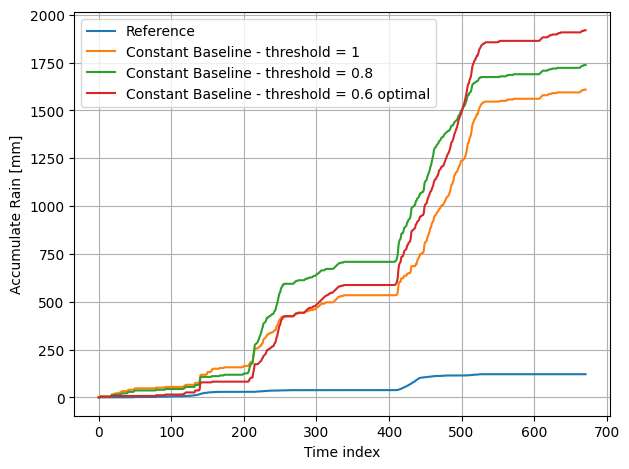

In [46]:
plt.plot(np.nancumsum(ref_15min), label="Reference")
plt.plot(np.nancumsum(rain_ts100), label="Constant Baseline - threshold = 1")
plt.plot(np.nancumsum(rain_ts80), label="Constant Baseline - threshold = 0.8")
plt.plot(np.nancumsum(rain_ts60), label="Constant Baseline - threshold = 0.6 optimal")
plt.xlabel("Time index")
plt.ylabel("Accumulate Rain [mm]")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()